<a href="https://colab.research.google.com/github/AnaRadulovic-research/statistika_prosjecna_plata/blob/main/diffusion_code_lab_Jialin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion Model

A standalone 1-hour code lab for building a small diffusion model from scratch.

By the end of this notebook, you should be able to trace the whole pipeline:

1. Start with clean MNIST images.
2. Add noise with a known forward process.
3. Train a neural network to predict the noise that was added.
4. Generate images by repeatedly denoising random noise.
5. Compare DDPM, DDIM, and a simple solver-style sampler.

The code is intentionally small. The goal is not state-of-the-art image quality; the goal is to make every moving part visible.

PDF roadmap for this lab:

- PDF pp. 3-5 motivate the generative modelling problem and the diffusion idea: generation is hard, so we learn to reverse a simple corruption process.
- PDF pp. 6-9 define the forward process and the closed-form noising equation used by `q_sample`.
- PDF pp. 10-15 introduce the learned reverse process, the noise-prediction objective, and the training/inference algorithms.
- PDF pp. 16-18 explain why a U-Net-style denoiser is a natural architecture and why predicting noise is one common parameterization.
- PDF pp. 19-24 discuss why DDPM sampling is slow and how DDIM reuses the same denoiser with fewer or more deterministic reverse steps.
- PDF pp. 25-26 motivate the continuous-time / ODE view that the simple solver section sketches.
- PDF p. 28 points toward extensions such as sequence or discrete-data diffusion, which the optional appendix mirrors with token masking.


## 1. Setup

This first cell imports the libraries, fixes random seeds, and selects the compute device.

If you are running on CPU, the notebook will still work, but training and sampling will be slower.

There is no diffusion math in this section yet. It just makes the rest of the notebook reproducible enough that sample differences usually come from model and sampler choices, not accidental randomness.


In [ ]:
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset

from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Fix all random seeds used in this notebook so the run is easier to reproduce.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use a GPU if one is available. The code also runs on CPU, but training is slower.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# timed() appends here so later demo cells can build a sampler speed table
# without rerunning every expensive sampler.
timing_log = []


def timed(label, fn):
    """Run a function and print wall-clock time, synchronizing CUDA for honest timings."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()
    result = fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    timing_log.append({"label": label, "seconds": elapsed})
    print(f"{label}: {elapsed:.2f} seconds")
    return result


device: cuda


## 2. Configuration

This cell is the lab switchboard. Almost every later section reads from these variables, so the comments below explain what each one controls.

For teaching, the safest knobs to change live are `LAB_MODE`, `SAMPLE_GUIDANCE`, `DDIM_EXPERIMENT_STRIDES`, and `DDIM_EXPERIMENT_ETAS`. The dataset, schedule, training, and model-capacity settings are also exposed, but changing them affects runtime and sample quality more strongly.

For a first pass on a GPU, keep `LAB_MODE = "full"`. If a machine is slow, switch to `"fast"`.

Conceptually, the most important configuration variables are `T`, `beta_start`, and `beta_end`. They define the forward noising chain from the PDF. The other knobs mostly control classroom runtime, model capacity, and which sampler comparisons are displayed.


In [ ]:
# ---------------------------------------------------------------------
# Classroom switchboard
# ---------------------------------------------------------------------
# LAB_MODE controls the runtime/quality preset.
# - "full": more training data/epochs and more diffusion steps; best on GPU.
# - "fast": smaller run for slow machines, demos, or CPU-only classrooms.
LAB_MODE = "full"  # Choose "fast" or "full".

# RUN_SEQUENCE_EXTENSION controls the optional discrete-token appendix.
# Keep this False for the main 1-hour live demo; switch to True for the after-class
# image-to-sequence extension.
RUN_SEQUENCE_EXTENSION = True

# LOAD_CHECKPOINT skips training if CHECKPOINT_PATH already exists.
LOAD_CHECKPOINT = False
# SAVE_CHECKPOINT writes trained weights after training so future runs can load them.
SAVE_CHECKPOINT = True
# CHECKPOINT_DIR is the folder where model checkpoints are stored.
CHECKPOINT_DIR = Path("checkpoints")


@dataclass
class Config:
    # image_size is the height/width of each square MNIST image in pixels.
    image_size: int = 28
    # channels is the number of image channels; MNIST is grayscale, so this is 1.
    channels: int = 1

    # T is the number of diffusion timesteps used for noising and reverse denoising.
    # Larger T gives a smoother reverse process but makes sampling slower.
    T: int = 500
    # beta_start is the first-step noise amount in the linear beta schedule.
    beta_start: float = 1e-4
    # beta_end is the final-step noise amount; larger values destroy signal faster.
    beta_end: float = 1e-2

    # batch_size controls how many images are used in one optimizer step.
    batch_size: int = 128
    # lr is the Adam learning rate.
    lr: float = 1e-3
    # train_subset limits how many MNIST training images are used to keep the lab fast.
    train_subset: int = 30000
    # val_subset limits how many validation images are used for diagnostics.
    val_subset: int = 2000
    # num_epochs is how many full passes over train_subset the model trains for.
    num_epochs: int = 20

    # base_channels sets the width of the tiny U-Net; larger is stronger but slower.
    base_channels: int = 64
    # time_dim is the size of the timestep embedding passed into the model blocks.
    time_dim: int = 128
    # num_classes is the number of digit labels, 0 through 9.
    num_classes: int = 10
    # cond_drop_prob randomly hides labels during training for classifier-free guidance.
    cond_drop_prob: float = 0.1


# The mode presets override only the fields that most affect classroom runtime.
if LAB_MODE == "fast":
    cfg = Config(
        T=200,
        train_subset=8000,
        val_subset=1000,
        num_epochs=5,
        base_channels=48,
        time_dim=96,
    )
elif LAB_MODE == "full":
    cfg = Config()
else:
    raise ValueError('LAB_MODE must be either "fast" or "full"')

# ---------------------------------------------------------------------
# Sampling and experiment knobs
# ---------------------------------------------------------------------
# SAMPLE_GRID_SIZE is how many images to generate in the sample grids.
SAMPLE_GRID_SIZE = 64
# SAMPLE_GUIDANCE is classifier-free guidance strength.
# scale=0 is unconditional, scale=1 is ordinary conditional sampling, and larger
# values usually follow labels more strongly but can reduce variety or quality.
SAMPLE_GUIDANCE = 2.0
# SAMPLE_LABELS assigns one target digit label per generated image, cycling 0, 1, ..., 9.
SAMPLE_LABELS = torch.arange(SAMPLE_GRID_SIZE, dtype=torch.long) % cfg.num_classes
# DEMO_DDIM_STRIDE keeps the live visual demos faster than full-step sampling.
DEMO_DDIM_STRIDE = 10
# CFG_DEMO_SCALES are shown side by side using the same starting noise.
CFG_DEMO_SCALES = [0.0, 1.0, 2.0, 4.0]
# DDIM_FULL_STRIDE=1 means DDIM uses every timestep instead of skipping steps.
DDIM_FULL_STRIDE = 1
# DDIM_EXPERIMENT_STRIDES are the timestep skip sizes compared in the DDIM speed/quality experiment.
DDIM_EXPERIMENT_STRIDES = [5, 10, 20, 50]
# DDIM_EXPERIMENT_ETAS are the stochasticity values compared in the DDIM eta experiment.
# eta=0 is deterministic for a fixed starting noise; larger eta injects more random noise.
DDIM_EXPERIMENT_ETAS = [0.0, 0.1, 0.3, 0.5, 1.0]
# DDIM_EXPERIMENT_STRIDE_FOR_ETA fixes the stride while eta changes.
DDIM_EXPERIMENT_STRIDE_FOR_ETA = 5
# SOLVER_STRIDE is the skip size used in the simple two-stage solver extension.
SOLVER_STRIDE = 10

# CHECKPOINT_PATH is the exact file used by LOAD_CHECKPOINT and SAVE_CHECKPOINT.
CHECKPOINT_PATH = CHECKPOINT_DIR / f"mnist_diffusion_{LAB_MODE}.pt"

print("LAB_MODE:", LAB_MODE)
print("checkpoint path:", CHECKPOINT_PATH)
cfg


LAB_MODE: full
checkpoint path: checkpoints/mnist_diffusion_full.pt


Config(image_size=28, channels=1, T=500, beta_start=0.0001, beta_end=0.01, batch_size=128, lr=0.001, train_subset=30000, val_subset=2000, num_epochs=20, base_channels=64, time_dim=128, num_classes=10, cond_drop_prob=0.1)

## 3. Load MNIST

MNIST is useful here because it is small, fast, and visually easy to inspect.

We map pixel values from `[0, 1]` to `[-1, 1]`. This is a common convention for diffusion models because the model output is centered around zero, like Gaussian noise.

In the PDF, `x_0` means a clean data sample. In this notebook, each MNIST image loaded here is one possible `x_0`. Later sections will turn these clean digits into noisy versions `x_t`, then train a model to reverse that corruption.


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),  # Map [0, 1] pixels to [-1, 1].
])

# Download MNIST if needed. The transform is applied lazily when samples are loaded.
full_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Keep a fixed train/validation split, then use subsets to keep the lab fast.
train_base, val_base = random_split(full_train, [55000, 5000])
train_set = Subset(train_base, list(range(cfg.train_subset)))
val_set = Subset(val_base, list(range(cfg.val_subset)))

# pin_memory helps GPU transfer speed when CUDA is available.
train_loader = DataLoader(
    train_set, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_set, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True
)

print("train subset:", len(train_set))
print("val subset:", len(val_set))


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 571kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

train subset: 30000
val subset: 2000


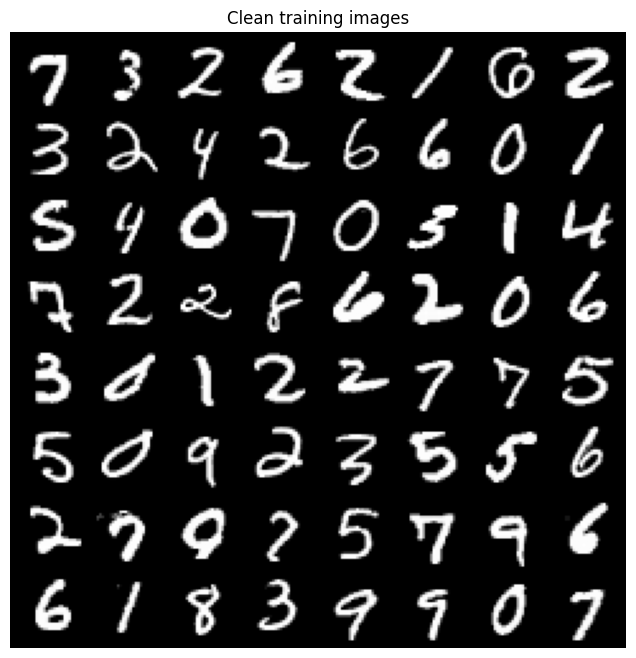

labels: [7, 3, 2, 6, 2, 1, 6, 2, 3, 2, 4, 2, 6, 6, 0, 1]


In [ ]:
def show_images(batch, title="", nrow=8, figsize=(8, 8)):
    """Show a grid of images stored in the notebook's [-1, 1] convention."""
    batch = batch.detach().cpu()
    batch = ((batch + 1.0) / 2.0).clamp(0, 1)  # Convert back to displayable [0, 1].
    grid = make_grid(batch[:nrow * nrow], nrow=nrow, padding=2)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Keep one batch around for visualization cells below.
x0_batch, labels = next(iter(train_loader))
show_images(x0_batch, title="Clean training images", nrow=8, figsize=(8, 8))
print("labels:", labels[:16].tolist())


## 4. Build the schedule

This section corresponds to the PDF's "From data to noise", "Forward process", and "Closed-form noising" slides.

The PDF first defines diffusion as a forward Markov chain that gradually destroys the data distribution. We choose that corruption process ourselves, so it should be simple, fixed, and analytically tractable.

The forward process gradually adds Gaussian noise to the data.

One small step is:

$x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\epsilon_t,
\qquad \epsilon_t \sim \mathcal{N}(0, I)$

where `beta_t` controls how much new noise is injected at timestep `t`. Small `beta_t` means the digit is only slightly corrupted; larger `beta_t` means the transition forgets more of the previous image.

We usually make `beta_t` larger at later timesteps, so early noisy images still look like digits and late noisy images look almost like pure noise. In this notebook, `beta_t` increases from `t=0` to `t=T-1`.

The code also defines `alpha_t = 1 - beta_t`. A single step keeps a fraction `alpha_t` of the previous signal, while the product `alphabar_t` keeps track of how much of the original clean image survives after many steps.

During training, we do not simulate every small step. Instead, we use the closed-form expression:

$x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I)$

where

$\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

Intuition: `alphabar_t` is the amount of original signal left after `t` noising steps.

The SNR plot is another way to read the same story. Signal-to-noise ratio is approximately `alphabar_t / (1 - alphabar_t)`: high SNR means the digit dominates the noise, while low SNR means the noise dominates the digit. This is useful later when diagnosing which timesteps the denoiser finds difficult.


In [ ]:
# A linear beta schedule is simple and easy to inspect.
betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.T, dtype=torch.float32)
alphas = 1.0 - betas

# alphabar_t is the cumulative product of alphas: how much original signal remains.
alphabars = torch.cumprod(alphas, dim=0)

# Precompute square roots because they appear repeatedly in q_sample and samplers.
sqrt_alphabars = torch.sqrt(alphabars)
sqrt_one_minus_alphabars = torch.sqrt(1.0 - alphabars)

# Signal-to-noise ratio is useful for understanding which timesteps are hard.
snr = alphabars / (1.0 - alphabars + 1e-8)

print("beta range:", float(betas[0]), "->", float(betas[-1]))
print("alphabar[0], alphabar[-1]:", float(alphabars[0]), float(alphabars[-1]))


beta range: 9.999999747378752e-05 -> 0.009999999776482582
alphabar[0], alphabar[-1]: 0.9998999834060669 0.0793832391500473


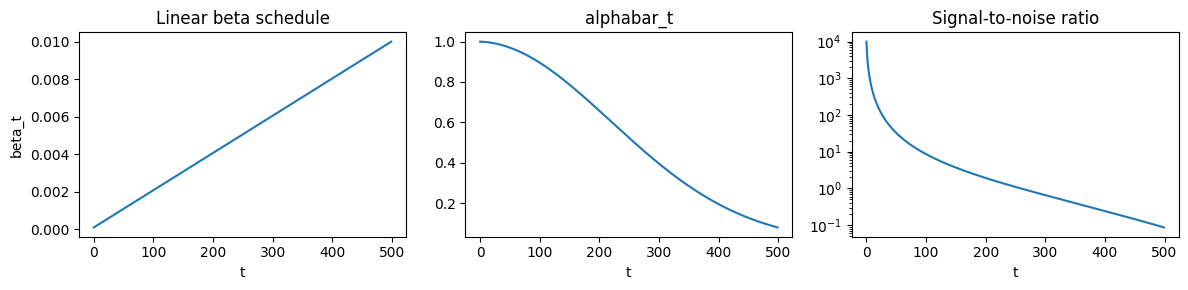

In [ ]:
# Visualize the schedule before using it. Students should check that beta increases
# and alphabar/SNR decrease as the image becomes more noisy.
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.plot(betas.numpy())
plt.title("Linear beta schedule")
plt.xlabel("t")
plt.ylabel("beta_t")

plt.subplot(1, 3, 2)
plt.plot(alphabars.numpy())
plt.title("alphabar_t")
plt.xlabel("t")

plt.subplot(1, 3, 3)
plt.plot(snr.numpy())
plt.yscale("log")
plt.title("Signal-to-noise ratio")
plt.xlabel("t")

plt.tight_layout()
plt.show()


## 5. Closed-form noising

This section implements the PDF's closed-form noising shortcut directly:

$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon$.

The important point is that every image in a batch can use a different timestep `t`. That is why the helper function `extract` reshapes schedule values so they broadcast correctly over image tensors.

This shortcut is what makes training efficient. Instead of simulating `x_0 -> x_1 -> ... -> x_t` for every training example, we sample one Gaussian noise tensor `epsilon` and jump straight to the chosen `x_t`. Mathematically this works because repeated Gaussian additions combine into one Gaussian with the variance shown in the PDF.

The visualization cells below are meant to separate two ideas that are easy to blur together: changing `t` changes the noise level, while changing `epsilon` changes the particular random corruption at the same noise level.


In [ ]:
def extract(a, t, x_shape):
    """Gather schedule values at batch timesteps and reshape for image broadcasting."""
    out = a.gather(0, t.cpu()).to(t.device)
    return out.view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    """Closed-form forward noising q(x_t | x_0), as in the lecture/PDF."""
    if noise is None:
        noise = torch.randn_like(x0)

    # This is the shortcut from the closed-form noising slide:
    # x_t = sqrt(alphabar_t) * x_0 + sqrt(1 - alphabar_t) * epsilon.
    # Because the Gaussian noises combine analytically, training can jump to any t
    # instead of simulating the whole chain 0 -> 1 -> ... -> t.
    # Each image can have its own t, so schedule values are gathered per example.
    return (
        extract(sqrt_alphabars, t, x0.shape) * x0
        + extract(sqrt_one_minus_alphabars, t, x0.shape) * noise
    )


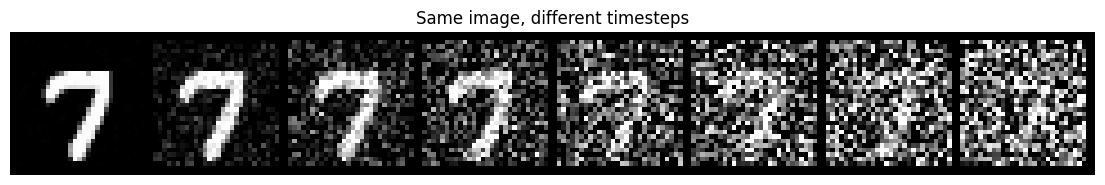

In [ ]:
# Track one clean image across several timesteps.
x0_vis = x0_batch[:1].to(device)
num_preview_steps = min(8, cfg.T)
timesteps = torch.linspace(0, cfg.T - 1, steps=num_preview_steps, device=device).round().long().unique()

noised_imgs = []
for t in timesteps:
    # q_sample can jump directly to timestep t without simulating all earlier steps.
    xt = q_sample(x0_vis, torch.tensor([int(t.item())], device=device))
    noised_imgs.append(xt[0].cpu())

show_images(torch.stack(noised_imgs), title="Same image, different timesteps", nrow=len(noised_imgs), figsize=(14, 3))


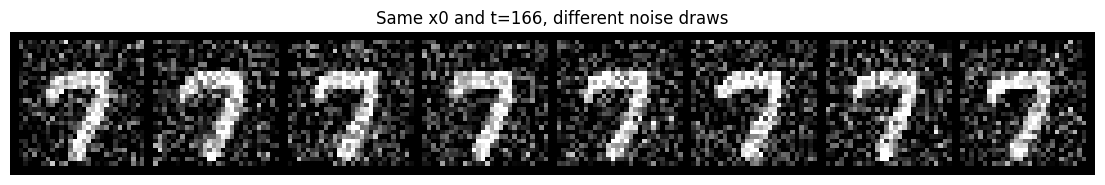

In [ ]:
# Same clean image and same timestep, but different Gaussian noise draws.
# This shows that q(x_t | x_0) is a distribution, not a single deterministic image.
t_fixed = torch.tensor([min(cfg.T - 1, max(0, cfg.T // 3))], device=device)
same_t_many_noises = []
for _ in range(8):
    xt = q_sample(x0_vis, t_fixed)
    same_t_many_noises.append(xt[0].cpu())

show_images(torch.stack(same_t_many_noises), title=f"Same x0 and t={int(t_fixed.item())}, different noise draws", nrow=8, figsize=(14, 2.5))


## 6. Tiny U-Net-style denoiser

This is the compact code version of the PDF's U-Net slide: downsample for broader context, upsample for details, and use a skip connection to preserve information.

The PDF often writes the denoiser as `epsilon_theta(x_t, t)`. This notebook uses the conditional version `epsilon_theta(x_t, t, y)`, where `y` is the requested digit label. The label is not concatenated as an extra image channel; it is embedded as a vector and added to the timestep embedding before being injected into each residual block.

The model receives three pieces of information:

- `x_t`: the noisy image.
- `t`: the noise level / timestep, so the network knows whether it is removing a little noise or almost all noise.
- `y`: the digit label, with an extra null label for unconditional training and classifier-free guidance.

The model outputs `epsilon_theta(x_t, t, y)`, an estimate of the exact Gaussian noise that was added to the clean image.

This is the epsilon-parameterization from the PDF's parameterization discussion. Other diffusion models may predict `x_0` directly or use `v`-prediction, but predicting noise is the simplest choice for this lab because the training target is exactly the sampled `epsilon` tensor.

This is only a tiny U-Net-style network: one downsample, two middle blocks, one upsample, and a skip connection. It is deliberately compact so students can read it during a live session.


In [ ]:
class TimeEmbedding(nn.Module):
    """Sinusoidal timestep embedding followed by a small MLP."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, t):
        # The lecture writes the denoiser as epsilon_theta(x_t, t). This embedding is
        # how the integer timestep t reaches the convolutional network.
        # Nearby timesteps get related vectors, which helps the model share behavior
        # across similar noise levels.
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / max(half - 1, 1)
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return self.mlp(emb)


class ResBlock(nn.Module):
    """A small residual block conditioned on timestep and label information."""

    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.cond_proj = nn.Linear(cond_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # The U-Net slide conditions on t; this lab also conditions on label y.
        # Project the combined condition to one bias per output channel, then broadcast
        # it over all pixels. Shape: [B, C] -> [B, C, 1, 1].
        h = h + self.cond_proj(cond)[:, :, None, None]

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)
        return h + self.skip(x)


class TinyUNet(nn.Module):
    """A compact U-Net-style denoiser for MNIST."""

    def __init__(self, in_ch=1, base=64, t_dim=128, num_label_tokens=11):
        super().__init__()
        self.time = TimeEmbedding(t_dim)
        self.label_emb = nn.Embedding(num_label_tokens, t_dim)
        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1)

        # Down path: the U-Net lecture slide describes downsampling as the part that
        # builds more global context. The skip connection below will preserve details.
        self.down1 = ResBlock(base, base, t_dim)
        self.downsample = nn.Conv2d(base, base * 2, kernel_size=4, stride=2, padding=1)

        # Middle path: wider, lower-resolution features summarize the digit shape.
        self.mid1 = ResBlock(base * 2, base * 2, t_dim)
        self.mid2 = ResBlock(base * 2, base * 2, t_dim)

        # Up path: return to image resolution and combine global shape with the
        # high-resolution strokes saved by the skip connection.
        self.upsample = nn.ConvTranspose2d(base * 2, base, kernel_size=4, stride=2, padding=1)
        self.up1 = ResBlock(base * 2, base, t_dim)

        self.out_norm = nn.GroupNorm(8, base)
        self.out_conv = nn.Conv2d(base, in_ch, 3, padding=1)

    def forward(self, x, t, y):
        # y is used here through label_emb, not by concatenating it to the image.
        # Adding time and label embeddings gives every residual block the two pieces
        # of context needed for conditional denoising: noise level and requested digit.
        cond = self.time(t) + self.label_emb(y)

        x1 = self.in_conv(x)
        x1 = self.down1(x1, cond)

        x2 = self.downsample(x1)
        x2 = self.mid1(x2, cond)
        x2 = self.mid2(x2, cond)

        x3 = self.upsample(x2)
        x3 = torch.cat([x3, x1], dim=1)  # U-Net skip connection: recover fine strokes.
        x3 = self.up1(x3, cond)

        x3 = self.out_norm(x3)
        x3 = F.silu(x3)
        # DDPM commonly uses epsilon-parameterization: predict noise, not the clean x_0.
        return self.out_conv(x3)  # Same shape as x: predicted noise epsilon.


# Extra label token used when we intentionally hide the class label.
# This gives the same network an unconditional branch for classifier-free guidance.
null_label = cfg.num_classes
model = TinyUNet(in_ch=cfg.channels, base=cfg.base_channels, t_dim=cfg.time_dim, num_label_tokens=cfg.num_classes + 1).to(device)
print("parameter count:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

# Quick shape check before training.
dummy_x = torch.randn(4, cfg.channels, cfg.image_size, cfg.image_size, device=device)
dummy_t = torch.randint(0, cfg.T, (4,), device=device)
dummy_y = torch.randint(0, cfg.num_classes + 1, (4,), device=device)
dummy_out = model(dummy_x, dummy_t, dummy_y)
print("output shape:", tuple(dummy_out.shape))


parameter count: 1.231041 M
output shape: (4, 1, 28, 28)


## 7. Training objective

This mirrors the PDF's "Core idea: predict the noise" and "Training algorithm" slides.

The key move is that the forward process gives us supervised labels for free. When we create `x_t`, we know the exact Gaussian noise `epsilon` used to create it, so the denoising network can be trained with ordinary regression.

Each training step follows the same recipe:

1. Pick a clean image `x0` and label `y`.
2. Sample a random timestep `t`.
3. Add known Gaussian noise to create `xt`.
4. Train the model to predict that exact noise.

The target is not the clean image. The target is the sampled noise tensor. This keeps the loss simple: mean squared error between predicted noise and true noise.

In PDF notation, the training objective is the practical version of `||epsilon - epsilon_theta(x_t, t, y)||^2`. Sampling `t` uniformly means one optimizer step teaches the model about one randomly chosen noise level, and the full training loop gradually covers the whole noising schedule.

The label dropout function is for classifier-free guidance. During training, the model sometimes sees a null label, so at sampling time we can compare conditional and unconditional predictions. That comparison lets us steer samples toward a label without training a separate classifier.


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)


def dropout_labels(y, drop_prob):
    """Replace some class labels with the null label for classifier-free guidance."""
    y_cond = y.clone()
    if drop_prob > 0:
        drop_mask = torch.rand(y.shape, device=y.device) < drop_prob
        y_cond[drop_mask] = null_label
    return y_cond


def diffusion_loss(model, x0, y):
    """DDPM noise-prediction objective from the lecture training algorithm."""
    b = x0.shape[0]

    # Match the PDF recipe: sample x_0 from data, sample a timestep t,
    # sample Gaussian epsilon, construct x_t, then train epsilon_theta(x_t, t, y)
    # to predict that exact epsilon.
    # Use a different random timestep for each example so one batch covers many
    # noise levels, from almost clean digits to almost pure noise.
    t = torch.randint(0, cfg.T, (b,), device=x0.device)
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)

    # Sometimes hide the label so the same model also learns an unconditional
    # prediction. Sampling will compare the conditional and unconditional outputs.
    y_cond = dropout_labels(y, cfg.cond_drop_prob)
    pred = model(xt, t, y_cond)
    # This is the simple loss from the training slide: E ||epsilon - epsilon_theta||^2.
    return F.mse_loss(pred, noise)


@torch.no_grad()
def evaluate(model, loader, max_batches=30):
    """Estimate validation loss on a limited number of batches to keep the lab fast."""
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(device)
        y = y.to(device)
        losses.append(diffusion_loss(model, x, y).item())
    return float(np.mean(losses)) if losses else float("nan")


@torch.no_grad()
def predict_eps_cfg(model, x, t, y, guidance_scale=1.0):
    """Predict noise with classifier-free guidance.

    CFG convention used here: scale=0 is unconditional, scale=1 is the normal
    conditional model, and scale>1 pushes harder toward the requested label.
    """
    # Conditional branch: what noise would explain x_t if the requested label is y?
    eps_cond = model(x, t, y)
    if guidance_scale == 1.0:
        return eps_cond

    # Unconditional branch: run the same network with the null label learned above.
    null_y = torch.full_like(y, null_label)
    eps_uncond = model(x, t, null_y)

    # Move from the unconditional prediction toward the conditional one.
    # scale=0 ignores y, scale=1 gives eps_cond, and larger scales exaggerate the
    # label direction.
    return eps_uncond + guidance_scale * (eps_cond - eps_uncond)


In [ ]:
train_losses, val_losses = [], []
loaded_checkpoint = False

if LOAD_CHECKPOINT:
    if CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        train_losses = checkpoint.get("train_losses", [])
        val_losses = checkpoint.get("val_losses", [])
        loaded_checkpoint = True
        print(f"loaded checkpoint from {CHECKPOINT_PATH}")
    else:
        print(f"checkpoint not found at {CHECKPOINT_PATH}; training from scratch")

if not loaded_checkpoint:
    train_start = time.perf_counter()

    for epoch in range(cfg.num_epochs):
        model.train()
        epoch_losses = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            # Standard PyTorch training step: forward, loss, backward, optimizer update.
            optimizer.zero_grad(set_to_none=True)
            loss = diffusion_loss(model, x, y)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        train_loss = float(np.mean(epoch_losses))
        val_loss = evaluate(model, val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}")

    print(f"training time: {time.perf_counter() - train_start:.2f} seconds")

    if SAVE_CHECKPOINT:
        CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "cfg": cfg.__dict__,
                "lab_mode": LAB_MODE,
            },
            CHECKPOINT_PATH,
        )
        print(f"saved checkpoint to {CHECKPOINT_PATH}")


epoch 00 | train 0.1258 | val 0.0642
epoch 01 | train 0.0619 | val 0.0572
epoch 02 | train 0.0540 | val 0.0537
epoch 03 | train 0.0510 | val 0.0500
epoch 04 | train 0.0489 | val 0.0491
epoch 05 | train 0.0480 | val 0.0484
epoch 06 | train 0.0471 | val 0.0465
epoch 07 | train 0.0463 | val 0.0475
epoch 08 | train 0.0465 | val 0.0473
epoch 09 | train 0.0456 | val 0.0453
epoch 10 | train 0.0452 | val 0.0445
epoch 11 | train 0.0449 | val 0.0455
epoch 12 | train 0.0443 | val 0.0452
epoch 13 | train 0.0448 | val 0.0438
epoch 14 | train 0.0438 | val 0.0454
epoch 15 | train 0.0441 | val 0.0449
epoch 16 | train 0.0438 | val 0.0443
epoch 17 | train 0.0437 | val 0.0429
epoch 18 | train 0.0435 | val 0.0436
epoch 19 | train 0.0431 | val 0.0436
training time: 369.01 seconds
saved checkpoint to checkpoints/mnist_diffusion_full.pt


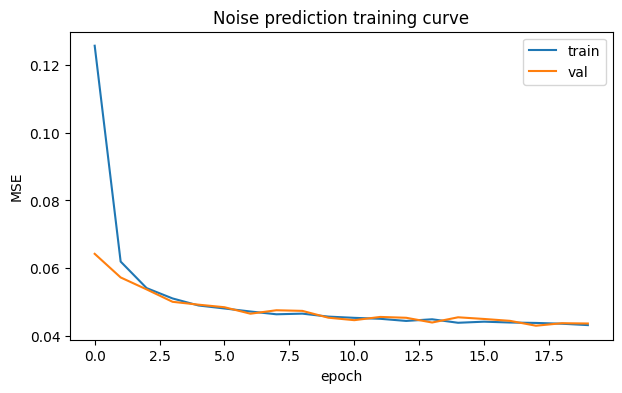

In [ ]:
# The absolute MSE value is less important than the trend: it should fall and then stabilize.
if train_losses and val_losses:
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.title("Noise prediction training curve")
    plt.legend()
    plt.show()
else:
    print("No training curve available. Train the model or load a checkpoint that stores losses.")


### Demo: one image, one noisy timestep

This cell makes the noise-prediction objective visible. We take one validation-style image, add a known noise tensor at one timestep, ask the trained U-Net to predict that noise, and then reconstruct `x0_hat` from the predicted noise.

This is one concrete example of the PDF's training algorithm. The model is not given the clean image directly; it only sees `(x_t, t, y)` and must infer the noise component that explains how `x_t` was produced.

The five panels answer five questions:

1. What was the clean input image `x0`?
2. What exact Gaussian noise `epsilon` did we add?
3. What noisy image `x_t` did the forward process produce?
4. What noise did the model predict from `(x_t, t, y)`?
5. If we remove the predicted noise using the closed-form equation, what clean image estimate `x0_hat` do we get?

It is a good place to point back to the PDF equation:

$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon$

Rearranging the same equation gives:

$\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar{\alpha}_t}\epsilon_\theta(x_t, t, y)}{\sqrt{\bar{\alpha}_t}}$

If the model predicts the noise perfectly, `x0_hat` should look like the original `x0`. If it is blurry or distorted, that usually means the denoiser's epsilon prediction is imperfect at this timestep, which is exactly what the displayed MSE measures.


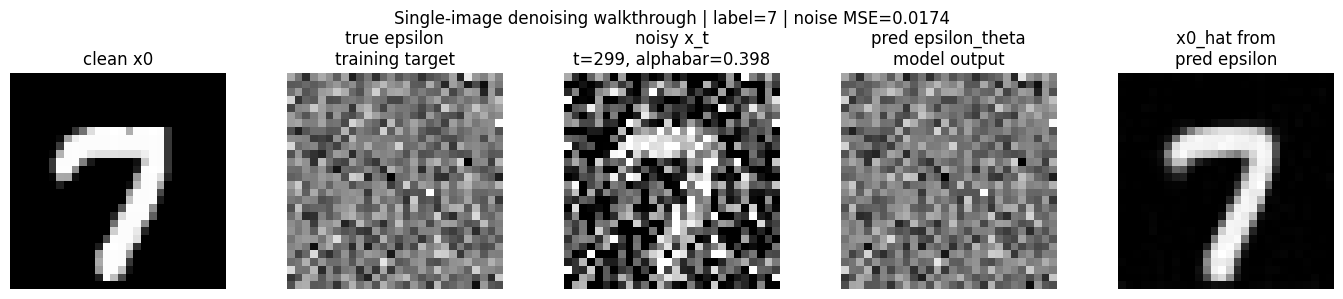

In [ ]:
@torch.no_grad()
def show_single_denoising_walkthrough(model, x0_source, label_source, t_value=None):
    """Visualize x0, epsilon, x_t, predicted epsilon, and reconstructed x0_hat."""
    model.eval()

    # Use just one image and its label so the visualization stays readable.
    # Shapes: x0 is [1, 1, 28, 28], y is [1].
    x0 = x0_source[:1].to(device)
    y = label_source[:1].to(device)
    if t_value is None:
        # Pick a fairly noisy timestep by default: not pure noise, but hard enough
        # that the denoising problem is visible.
        t_value = int(0.6 * (cfg.T - 1))
    t = torch.full((1,), t_value, device=device, dtype=torch.long)

    # During training we sample epsilon ourselves, so we know the exact target.
    # q_sample uses the closed-form forward process to make x_t directly.
    true_noise = torch.randn_like(x0)
    xt = q_sample(x0, t, true_noise)

    # The model sees only the noisy image, timestep, and label. Its job is to infer
    # the noise component that produced x_t.
    pred_noise = model(xt, t, y)

    # Rearrange x_t = sqrt(alphabar_t) x0 + sqrt(1 - alphabar_t) epsilon.
    # We plug in pred_noise for epsilon, so this is the model's clean-image estimate.
    alphabar_t = alphabars_t[t_value] if 'alphabars_t' in globals() else alphabars[t_value].to(device)
    x0_hat = (xt - torch.sqrt(1 - alphabar_t) * pred_noise) / torch.sqrt(alphabar_t)

    def image01(img):
        # MNIST tensors in this notebook live in [-1, 1]; matplotlib expects [0, 1].
        return ((img.detach().cpu()[0] + 1.0) / 2.0).clamp(0, 1).squeeze()

    def noise01(img):
        # Noise is not an image in [-1, 1]. Rescale it only for visualization, so
        # darker/lighter pixels show relative negative/positive noise values.
        img = img.detach().cpu()[0].squeeze()
        return (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Read these left to right as the full training story for one example.
    panels = [
        ("clean x0", image01(x0)),
        ("true epsilon\ntraining target", noise01(true_noise)),
        (f"noisy x_t\nt={t_value}, alphabar={float(alphabars[t_value]):.3f}", image01(xt)),
        ("pred epsilon_theta\nmodel output", noise01(pred_noise)),
        ("x0_hat from\npred epsilon", image01(x0_hat)),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(14, 3))
    for ax, (title, img) in zip(axes, panels):
        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(title)
        ax.axis("off")

    # MSE is measured in noise space because the training loss teaches the model
    # to predict epsilon, not x0 directly.
    mse = F.mse_loss(pred_noise, true_noise).item()
    fig.suptitle(f"Single-image denoising walkthrough | label={int(y.item())} | noise MSE={mse:.4f}")
    plt.tight_layout()
    plt.show()


show_single_denoising_walkthrough(model, x0_batch, labels)


## 8. Timestep diagnostics

A single validation loss can hide useful behavior.

Here we measure noise-prediction error separately across timestep ranges. This helps answer: is the model better at early, lightly noised images or later, heavily noised images?

This links back to the schedule section and the PDF's closed-form noising equation. Early timesteps have high SNR, so the digit structure is still visible. Late timesteps have low SNR, so the network must rely more on learned digit statistics and label conditioning.

When teaching, this is a good checkpoint: students can connect the curve back to the signal-to-noise ratio plot and ask whether errors are concentrated where the forward process has removed most of the signal.


In [ ]:
@torch.no_grad()
def bucketed_timestep_mse(model, loader, num_buckets=5, max_batches=20):
    """Measure denoising error separately for low, middle, and high noise levels."""
    model.eval()
    bucket_sums = np.zeros(num_buckets, dtype=np.float64)
    bucket_counts = np.zeros(num_buckets, dtype=np.int64)

    for batch_idx, (x0, y) in enumerate(loader):
        if batch_idx >= max_batches:
            break
        x0 = x0.to(device)
        y = y.to(device)
        b = x0.shape[0]

        # Sample fresh timesteps/noise so diagnostics match the training distribution.
        t = torch.randint(0, cfg.T, (b,), device=device)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)
        pred = model(xt, t, y)

        # Average pixel error per image, then assign each image to its timestep bucket.
        per_example = ((pred - noise) ** 2).view(b, -1).mean(dim=1)

        for i in range(b):
            bucket = min(num_buckets - 1, int((t[i].item() / cfg.T) * num_buckets))
            bucket_sums[bucket] += per_example[i].item()
            bucket_counts[bucket] += 1

    return bucket_sums / np.maximum(bucket_counts, 1)


bucket_mse = bucketed_timestep_mse(model, val_loader, num_buckets=10)
bucket_mse


array([0.11704233, 0.06986764, 0.05195605, 0.0412782 , 0.03480314,
       0.03054328, 0.02674832, 0.02282331, 0.01876452, 0.0154677 ])

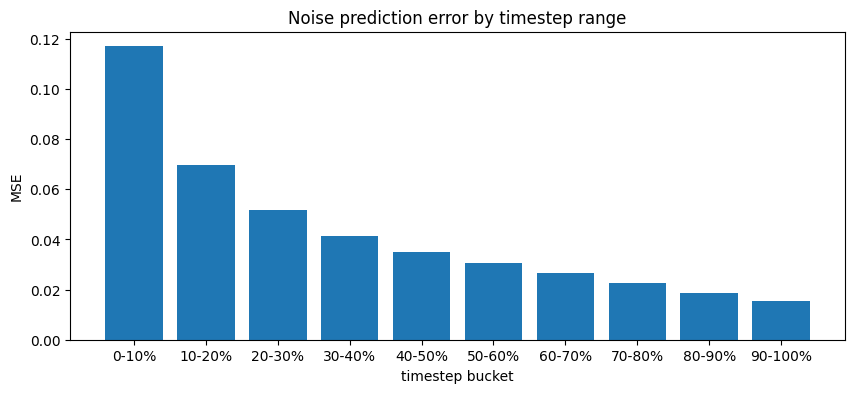

In [ ]:
# Lower buckets are early timesteps with more signal; higher buckets are later timesteps with more noise.
plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(bucket_mse)), bucket_mse)
plt.xticks(range(10), ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"])
plt.ylabel("MSE")
plt.xlabel("timestep bucket")
plt.title("Noise prediction error by timestep range")
plt.show()


## 9. DDPM sampling

This implements the PDF's inference algorithm: start from Gaussian noise and repeatedly apply a learned reverse step.

Training used the forward process `q(x_t | x_0)`. Sampling uses the learned reverse process.

We start from pure Gaussian noise `x_T` and repeatedly move toward less noisy images. At each step, the model predicts the noise component, and the DDPM update removes part of that noise while adding a small amount of fresh randomness.

The PDF emphasizes that the reverse distribution is learned because information was lost in the forward chain. In code, the predicted epsilon gives an estimate of the clean image direction, and the schedule terms decide how far to move from `x_t` toward `x_{t-1}`.

DDPM is slow for the same reason it is conceptually simple: it follows the reverse chain one timestep at a time. If `T=500`, one sample needs hundreds of U-Net evaluations.

This sampler is stochastic: running it twice with the same labels can produce different samples because fresh noise is injected during most reverse steps.


In [ ]:
# Move schedule tensors once so sampling does not repeatedly copy them to the device.
betas_t = betas.to(device)
alphas_t = alphas.to(device)
alphabars_t = alphabars.to(device)


def image_sample_shape(n):
    """Return the configured image tensor shape for n generated samples."""
    return (n, cfg.channels, cfg.image_size, cfg.image_size)


def record_timesteps(T):
    """Choose a small set of reverse-process timesteps to visualize."""
    candidates = {0, 1, 5, T // 10, T // 5, (2 * T) // 5, (4 * T) // 5, T - 1}
    return {max(0, min(T - 1, int(t))) for t in candidates}


def timestep_caption(t):
    """Compact caption connecting a timestep to signal left and signal-to-noise ratio."""
    return f"t={t}\nalphabar={float(alphabars[t]):.3f}\nSNR={float(snr[t]):.2g}"


@torch.no_grad()
def ddpm_sample(model, labels, guidance_scale=None, record=False):
    """Generate images with the stochastic DDPM reverse process."""
    if guidance_scale is None:
        guidance_scale = SAMPLE_GUIDANCE

    model.eval()
    labels = labels.to(device)
    n = labels.shape[0]

    # Inference starts where the forward process ends: pure Gaussian noise x_T.
    x = torch.randn(*image_sample_shape(n), device=device)
    snapshots = []
    save_steps = record_timesteps(cfg.T)

    for t in reversed(range(cfg.T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps = predict_eps_cfg(model, x, t_batch, labels, guidance_scale=guidance_scale)

        alpha_t = alphas_t[t]
        alphabar_t = alphabars_t[t]
        beta_t = betas_t[t]

        # DDPM inference slide: remove predicted noise, rescale by alpha_t,
        # then optionally add fresh randomness. This mean is the learned reverse step.
        mean = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alphabar_t)) * eps
        )

        if t > 0:
            # Stochastic part of DDPM: add fresh Gaussian noise at every reverse step
            # except the final step, where we want the clean image estimate.
            z = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * z
        else:
            x = mean

        # Save a few intermediate states for the trajectory plot.
        if record and t in save_steps:
            snapshots.append((t, x.detach().cpu()))

    return x.detach().cpu(), snapshots


DDPM sampling: 14.32 seconds


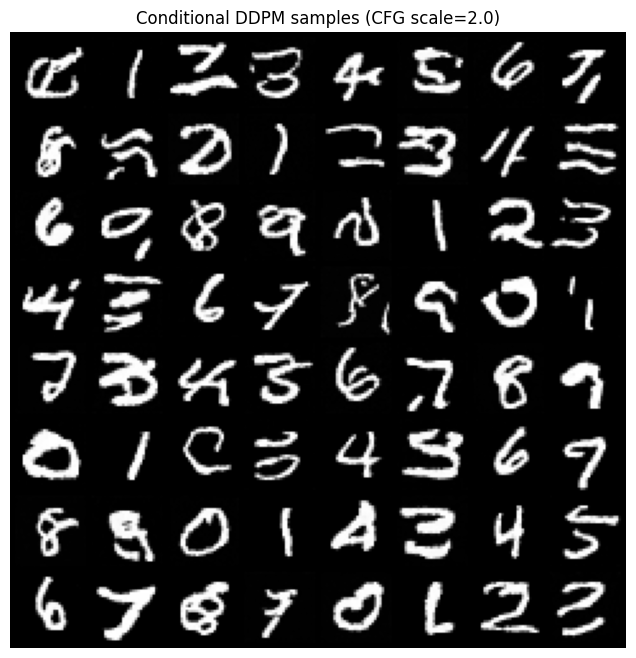

labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5]


In [ ]:
# Generate labels 0, 1, ..., 9, 0, 1, ... so the grid shows conditional control.
continuous_sample_labels = SAMPLE_LABELS.clone()
samples_ddpm, snapshots_ddpm = timed(
    "DDPM sampling",
    lambda: ddpm_sample(model, continuous_sample_labels, guidance_scale=SAMPLE_GUIDANCE, record=True),
)
show_images(samples_ddpm, title=f"Conditional DDPM samples (CFG scale={SAMPLE_GUIDANCE})", nrow=8, figsize=(8, 8))
print('labels:', continuous_sample_labels[:16].tolist())


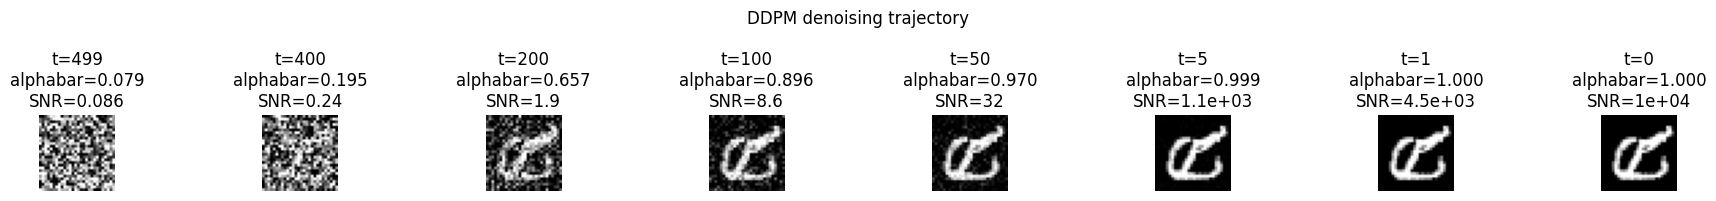

In [ ]:
# Show how one sample evolves from noise to image under the DDPM reverse process.
fig, axes = plt.subplots(1, len(snapshots_ddpm), figsize=(18, 2))
axes = np.atleast_1d(axes).ravel()
for ax, (t, batch) in zip(axes, sorted(snapshots_ddpm, key=lambda z: z[0], reverse=True)):
    img = ((batch[0] + 1) / 2).clamp(0, 1)
    ax.imshow(img.squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(timestep_caption(t))
    ax.axis("off")
plt.suptitle("DDPM denoising trajectory")
plt.tight_layout()
plt.show()


## 10. DDIM sampling

This connects to the PDF's DDPM vs DDIM and generalized DDIM slides.

DDIM uses the same trained model but changes the reverse update.

Instead of sampling a fresh random variable at every step, DDIM can be deterministic when `eta=0`. It also lets us skip timesteps with `step_stride`, which makes sampling much faster.

This matches the PDF's idea that DDIM defines a family of samplers. `step_stride` is the notebook's simple version of taking fewer reverse steps, and `eta` controls how stochastic those steps are. With `eta=0`, the same starting noise and labels should give the same image every time.

This is a key lesson: training the denoiser and choosing a sampler are related but separate design choices. The neural network still predicts epsilon; only the rule for moving from one noise level to the next has changed.


In [ ]:
@torch.no_grad()
def ddim_sample(model, labels, step_stride=1, eta=0.0, guidance_scale=None, record=False, x_start=None):
    """Generate images with generalized DDIM sampling."""
    if guidance_scale is None:
        guidance_scale = SAMPLE_GUIDANCE

    model.eval()
    labels = labels.to(device)
    n = labels.shape[0]
    # Same starting point as DDPM: x_T is Gaussian noise. For controlled demos we can
    # pass x_start so only the label or guidance scale changes between runs.
    if x_start is None:
        x = torch.randn(*image_sample_shape(n), device=device)
    else:
        x = x_start.to(device)
        if x.shape[0] == 1 and n > 1:
            x = x.repeat(n, 1, 1, 1)
        else:
            x = x.clone()
        assert tuple(x.shape) == image_sample_shape(n), f"x_start shape {tuple(x.shape)} does not match labels"

    # DDIM uses the same trained epsilon_theta but chooses a different reverse path.
    # Larger stride means fewer model calls, matching the PDF's fixed-step DDIM idea.
    times = list(range(cfg.T - 1, -1, step_stride * -1))
    if times[-1] != 0:
        times.append(0)
    snapshots = []

    for i in range(len(times) - 1):
        t = times[i]
        s = times[i + 1]

        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps = predict_eps_cfg(model, x, t_batch, labels, guidance_scale=guidance_scale)

        alphabar_t = alphabars_t[t]
        alphabar_s = alphabars_t[s]

        # First estimate the clean image x_0 from the current noisy image and predicted
        # noise. This rearranges the same closed-form noising equation used in q_sample.
        x0_hat = (x - torch.sqrt(1 - alphabar_t) * eps) / torch.sqrt(alphabar_t)

        # eta is the generalized DDIM noise knob from the PDF: eta=0 is deterministic
        # DDIM, while larger eta moves back toward a stochastic DDPM-like sampler.
        sigma = eta * torch.sqrt(
            (1 - alphabar_s) / (1 - alphabar_t) * (1 - alphabar_t / alphabar_s)
        ) if s > 0 else torch.tensor(0.0, device=device)

        # Re-noise x0_hat to the target lower timestep s. When eta=0 this follows a
        # deterministic path; when eta>0, sigma * noise adds controlled randomness.
        mean_part = torch.sqrt(alphabar_s) * x0_hat
        direction_part = torch.sqrt(torch.clamp(1 - alphabar_s - sigma**2, min=0.0)) * eps

        if eta > 0 and s > 0:
            noise = torch.randn_like(x)
            x = mean_part + direction_part + sigma * noise
        else:
            x = mean_part + direction_part

        if record and i in {0, len(times)//4, len(times)//2, 3*len(times)//4, len(times)-2}:
            snapshots.append((t, x.detach().cpu()))

    return x.detach().cpu(), snapshots


DDIM sampling: 14.31 seconds


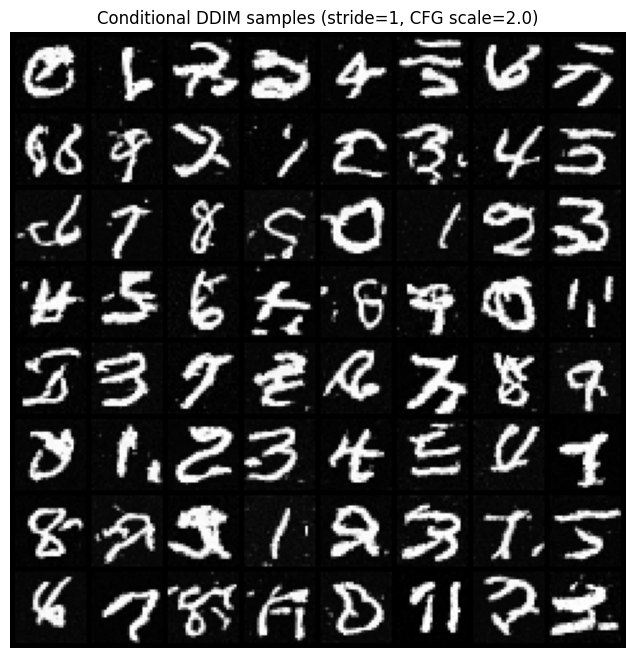

In [ ]:
# With step_stride=1 and eta=0, DDIM uses all timesteps but removes per-step randomness.
samples_ddim, snapshots_ddim = timed(
    "DDIM sampling",
    lambda: ddim_sample(
        model,
        continuous_sample_labels,
        step_stride=DDIM_FULL_STRIDE,
        eta=0.0,
        guidance_scale=SAMPLE_GUIDANCE,
        record=True,
    ),
)
show_images(samples_ddim, title=f"Conditional DDIM samples (stride={DDIM_FULL_STRIDE}, CFG scale={SAMPLE_GUIDANCE})", nrow=8, figsize=(8, 8))


### Demo: same starting noise, different labels

This isolates where `y` matters. We reuse the exact same initial Gaussian noise for labels 0 through 9, then run deterministic DDIM. The only intended difference between columns is the label embedding inside the U-Net conditioning vector.

This is a useful check after the U-Net section: the image tensor `x_T` is identical, but the condition vector changes. If the model learned conditional denoising, the same noise should be steered toward different digit classes.


DDIM same x_T, labels 0-9 stride=10: 0.29 seconds


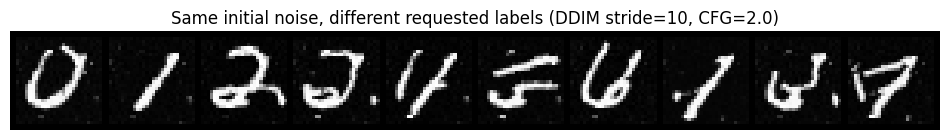

labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
label_demo_labels = torch.arange(cfg.num_classes, dtype=torch.long)
label_demo_noise = torch.randn(1, cfg.channels, cfg.image_size, cfg.image_size, device=device)

label_demo_samples, _ = timed(
    f"DDIM same x_T, labels 0-9 stride={DEMO_DDIM_STRIDE}",
    lambda: ddim_sample(
        model,
        label_demo_labels,
        step_stride=DEMO_DDIM_STRIDE,
        eta=0.0,
        guidance_scale=SAMPLE_GUIDANCE,
        record=False,
        x_start=label_demo_noise,
    ),
)
show_images(
    label_demo_samples,
    title=f"Same initial noise, different requested labels (DDIM stride={DEMO_DDIM_STRIDE}, CFG={SAMPLE_GUIDANCE})",
    nrow=cfg.num_classes,
    figsize=(12, 2),
)
print("labels:", label_demo_labels.tolist())


### Demo: classifier-free guidance strength

Here the labels and initial noise are fixed, while `guidance_scale` changes. This makes the trade-off easier to see: stronger guidance usually makes the requested digit clearer, but very large values can reduce variety or make samples look harsher.

Classifier-free guidance uses the null-label branch learned during training. In this notebook, `guidance_scale=0` uses the unconditional prediction, `guidance_scale=1` is ordinary conditional sampling, and larger values push the prediction further in the conditional direction.


DDIM CFG=0.0 stride=10: 0.38 seconds
DDIM CFG=1.0 stride=10: 0.19 seconds
DDIM CFG=2.0 stride=10: 0.38 seconds
DDIM CFG=4.0 stride=10: 0.38 seconds


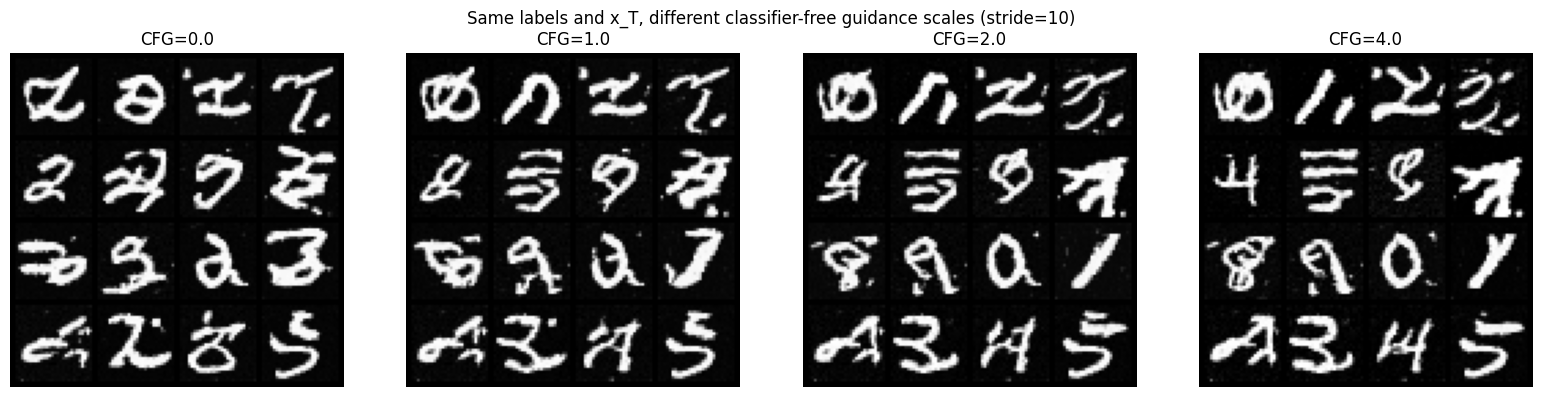

labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5]


In [ ]:
cfg_demo_labels = torch.arange(16, dtype=torch.long) % cfg.num_classes
cfg_demo_noise = torch.randn(*image_sample_shape(len(cfg_demo_labels)), device=device)

fig, axes = plt.subplots(1, len(CFG_DEMO_SCALES), figsize=(4 * len(CFG_DEMO_SCALES), 4))
axes = np.atleast_1d(axes).ravel()

for ax, scale in zip(axes, CFG_DEMO_SCALES):
    batch, _ = timed(
        f"DDIM CFG={scale} stride={DEMO_DDIM_STRIDE}",
        lambda scale=scale: ddim_sample(
            model,
            cfg_demo_labels,
            step_stride=DEMO_DDIM_STRIDE,
            eta=0.0,
            guidance_scale=scale,
            record=False,
            x_start=cfg_demo_noise,
        ),
    )
    grid = make_grid(((batch + 1) / 2).clamp(0, 1), nrow=4, padding=2)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"CFG={scale}")
    ax.axis("off")

plt.suptitle(f"Same labels and x_T, different classifier-free guidance scales (stride={DEMO_DDIM_STRIDE})")
plt.tight_layout()
plt.show()
print("labels:", cfg_demo_labels.tolist())


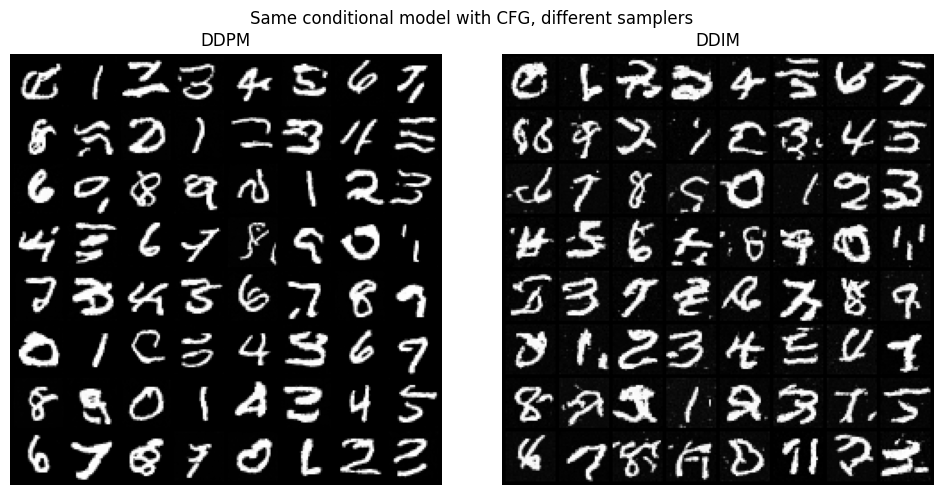

In [ ]:
# Compare stochastic DDPM and deterministic DDIM using the same trained model.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, batch, title in zip(axes, [samples_ddpm, samples_ddim], ["DDPM", "DDIM"]):
    grid = make_grid(((batch[:64] + 1) / 2).clamp(0, 1), nrow=8, padding=2)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Same conditional model with CFG, different samplers")
plt.tight_layout()
plt.show()


## 11. DDIM experiments

Now we use the same model and vary the sampler.

This is the practical version of the PDF's DDPM vs DDIM comparison. We are not retraining the model; we are asking how much sample quality changes when the reverse trajectory is evaluated with fewer steps or with extra stochasticity.

Two useful questions to ask while looking at the outputs:

- What happens when `step_stride` gets larger and the sampler takes fewer reverse steps?
- What happens when `eta` increases and we inject more randomness?

The samples are not expected to be perfect. The goal is to see the speed, quality, and randomness trade-offs. A good classroom reading is: larger stride means fewer model calls and more approximation error; larger `eta` means more injected randomness and less deterministic reconstruction from the same `x_T`.


DDIM stride=5: 0.75 seconds
DDIM stride=10: 0.38 seconds
DDIM stride=20: 0.19 seconds
DDIM stride=50: 0.08 seconds


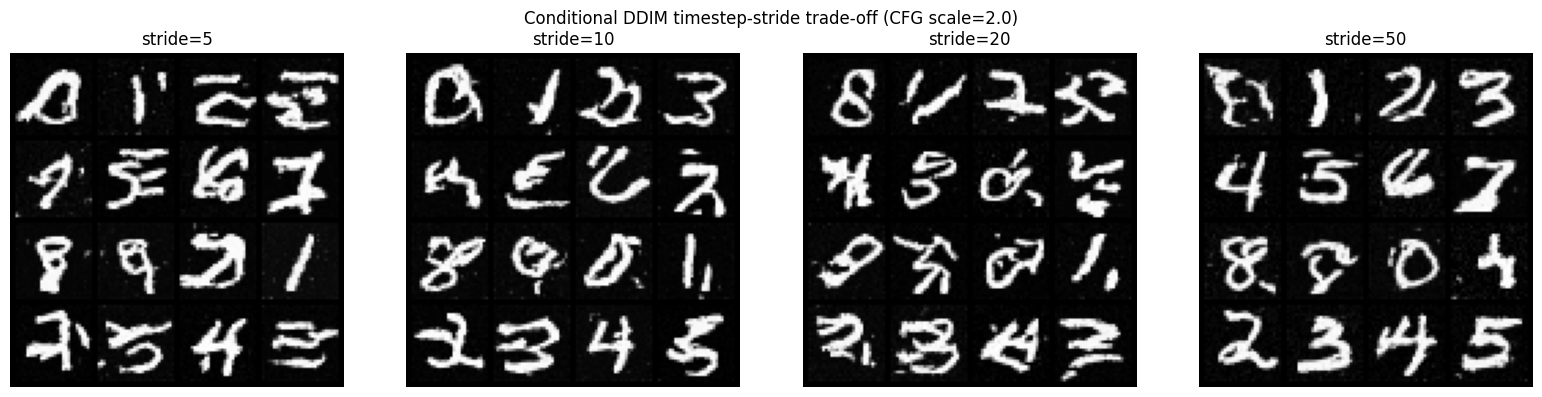

In [ ]:
# Larger stride means fewer reverse steps and fewer neural-network evaluations.
stride_options = DDIM_EXPERIMENT_STRIDES
fig, axes = plt.subplots(1, len(stride_options), figsize=(16, 4))

for ax, stride in zip(axes, stride_options):
    batch, _ = timed(
        f"DDIM stride={stride}",
        lambda stride=stride: ddim_sample(
            model,
            continuous_sample_labels[:16],
            step_stride=stride,
            eta=0.0,
            guidance_scale=SAMPLE_GUIDANCE,
            record=False,
        ),
    )
    grid = make_grid(((batch[:16] + 1) / 2).clamp(0, 1), nrow=4, padding=2)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"stride={stride}")
    ax.axis("off")

plt.suptitle(f"Conditional DDIM timestep-stride trade-off (CFG scale={SAMPLE_GUIDANCE})")
plt.tight_layout()
plt.show()


DDIM eta=0.0: 0.75 seconds
DDIM eta=0.1: 0.78 seconds
DDIM eta=0.3: 0.75 seconds
DDIM eta=0.5: 0.75 seconds
DDIM eta=1.0: 0.75 seconds


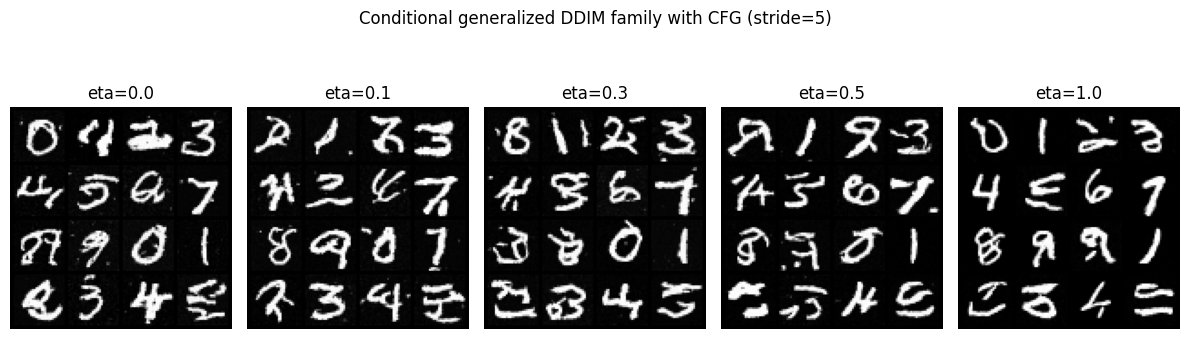

In [ ]:
# eta controls stochasticity. eta=0 is deterministic; larger eta injects more noise.
eta_options = DDIM_EXPERIMENT_ETAS
fig, axes = plt.subplots(1, len(eta_options), figsize=(12, 4))

for ax, eta in zip(axes, eta_options):
    batch, _ = timed(
        f"DDIM eta={eta}",
        lambda eta=eta: ddim_sample(
            model,
            continuous_sample_labels[:16],
            step_stride=DDIM_EXPERIMENT_STRIDE_FOR_ETA,
            eta=eta,
            guidance_scale=SAMPLE_GUIDANCE,
            record=False,
        ),
    )
    grid = make_grid(((batch[:16] + 1) / 2).clamp(0, 1), nrow=4, padding=2)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"eta={eta}")
    ax.axis("off")

plt.suptitle(f"Conditional generalized DDIM family with CFG (stride={DDIM_EXPERIMENT_STRIDE_FOR_ETA})")
plt.tight_layout()
plt.show()


### Demo note: expected trade-offs

If one of these demos looks imperfect, that is usually a useful teaching moment rather than a bug. In `fast` mode or with few epochs, samples can be fuzzy because the denoiser has not learned enough. With large DDIM strides, errors accumulate because the sampler skips many reverse steps. With very large CFG, labels can become clearer while texture and variety get worse.

This mirrors the PDF's limitation slides: diffusion quality depends both on the learned score/denoiser and on how accurately the sampler follows the reverse trajectory.

For live debugging, first check the training curve and the timestep MSE plot, then reduce `DDIM_EXPERIMENT_STRIDES` or lower `SAMPLE_GUIDANCE` before changing the model architecture.


### Code lab questions

Use this section to pause and reason before moving on:

- If `step_stride` is large, why might samples get worse?
- If `eta=0`, where does sample diversity still come from?
- Why can DDPM and DDIM use the same trained denoising model?
- How does classifier-free guidance use the unconditional branch learned during label dropout?
- What would you change first if sampling quality is poor: training epochs, model size, beta schedule, or sampler settings?


## 12. Simple solver example

This connects to the PDF's continuous-time / ODE view and solver slides.

This is a lightweight advanced extension.

We will not derive a full DPM-Solver. Instead, we build a simple two-stage correction:

1. Take one DDIM-style prediction step.
2. Re-evaluate the model at the predicted next point.
3. Average the two noise predictions and step again.

The point is numerical intuition: better estimates of the reverse trajectory can improve large-step sampling.

Read this as a toy predictor-corrector method, not as a production DPM-Solver implementation. It uses the same epsilon-predicting model, but spends an extra model evaluation to get a better local direction before taking a large reverse step.


solver-style sampling stride=10: 2.82 seconds
DDIM comparison stride=10: 1.43 seconds


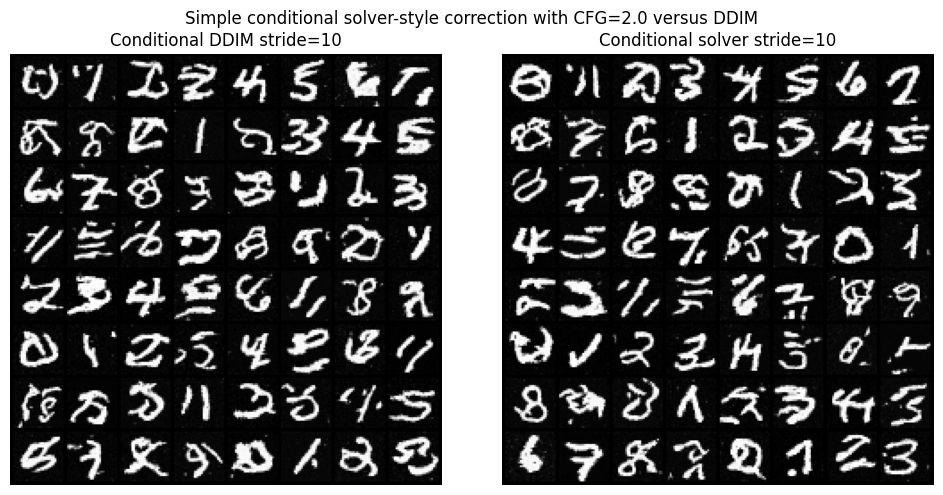

In [ ]:
@torch.no_grad()
def ddim_step_from_eps(x, eps, t, s):
    """One deterministic DDIM-style step from timestep t to a lower timestep s."""
    alphabar_t = alphabars_t[t]
    alphabar_s = alphabars_t[s]

    # Same algebra as DDIM above: estimate x_0, then re-noise it to timestep s
    # using the same eps direction. This is the Euler-style first-order step.
    x0_hat = (x - torch.sqrt(1 - alphabar_t) * eps) / torch.sqrt(alphabar_t)
    x_next = torch.sqrt(alphabar_s) * x0_hat + torch.sqrt(1 - alphabar_s) * eps
    return x_next, x0_hat


@torch.no_grad()
def solver_sample(model, labels, step_stride=10, guidance_scale=None, record=False):
    """A simple two-stage correction built on top of DDIM steps."""
    if guidance_scale is None:
        guidance_scale = SAMPLE_GUIDANCE

    model.eval()
    labels = labels.to(device)
    n = labels.shape[0]
    x = torch.randn(*image_sample_shape(n), device=device)

    times = list(range(cfg.T - 1, -1, -step_stride))
    if times[-1] != 0:
        times.append(0)
    snapshots = []

    for i in range(len(times) - 1):
        t = times[i]
        s = times[i + 1]

        # Stage 1: use the current point to make an Euler/DDIM-style prediction.
        # This connects to the PDF's ODE view: sampling is solving a trajectory
        # backward from noise to data, and plain DDIM is a first-order solver.
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps_t = predict_eps_cfg(model, x, t_batch, labels, guidance_scale=guidance_scale)
        x_euler, _ = ddim_step_from_eps(x, eps_t, t, s)

        if s > 0:
            # Stage 2: evaluate the model again at the predicted next point.
            # This gives a second slope/noise estimate, like a small predictor-corrector
            # step, so large strides do not rely on only one local estimate.
            s_batch = torch.full((n,), s, device=device, dtype=torch.long)
            eps_s = predict_eps_cfg(model, x_euler, s_batch, labels, guidance_scale=guidance_scale)

            # Average the two slope/noise estimates before taking the final step.
            eps_avg = 0.5 * (eps_t + eps_s)
            x, _ = ddim_step_from_eps(x, eps_avg, t, s)
        else:
            x = x_euler

        if record and i in {0, len(times)//4, len(times)//2, 3*len(times)//4, len(times)-2}:
            snapshots.append((t, x.detach().cpu()))

    return x.detach().cpu(), snapshots


solver_stride = SOLVER_STRIDE
samples_solver, snapshots_solver = timed(
    f"solver-style sampling stride={solver_stride}",
    lambda: solver_sample(model, continuous_sample_labels, step_stride=solver_stride, guidance_scale=SAMPLE_GUIDANCE, record=True),
)
samples_ddim_solver_cmp, _ = timed(
    f"DDIM comparison stride={solver_stride}",
    lambda: ddim_sample(model, continuous_sample_labels, step_stride=solver_stride, eta=0.0, guidance_scale=SAMPLE_GUIDANCE, record=False),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, batch, title in zip(
    axes,
    [samples_ddim_solver_cmp, samples_solver],
    [f'Conditional DDIM stride={solver_stride}', f'Conditional solver stride={solver_stride}'],
):
    grid = make_grid(((batch[:64] + 1) / 2).clamp(0, 1), nrow=8, padding=2)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray', vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.axis('off')

plt.suptitle(f'Simple conditional solver-style correction with CFG={SAMPLE_GUIDANCE} versus DDIM')
plt.tight_layout()
plt.show()


### Sampler speed table

This table uses the same benchmark batch for every sampler row and runs each benchmark with `record=False`, so trajectory-plot bookkeeping does not affect the comparison. Use it to connect the PDF's DDPM/DDIM/solver discussion to what happened in this notebook run.

The two columns to compare are wall-clock seconds and approximate model calls. DDPM usually has many calls because it walks through the full chain. DDIM and the solver-style sampler can be faster because they take a shorter trajectory through the same noise schedule.


DDPM benchmark batch=64: 14.29 seconds
DDIM benchmark stride=1 batch=64: 14.29 seconds
DDIM benchmark stride=10 batch=64: 1.43 seconds
solver benchmark stride=10 batch=64: 2.84 seconds
     sampler |        batch |        steps |  model calls |          eta |         time
----------------------------------------------------------------------------------
        DDPM |           64 |          500 |          500 |   stochastic |       14.29s
DDIM stride=1 |           64 |          499 |          499 |            0 |       14.29s
DDIM stride=10 |           64 |           50 |           50 |            0 |        1.43s
solver stride=10 |           64 |           50 |           99 |            0 |        2.84s


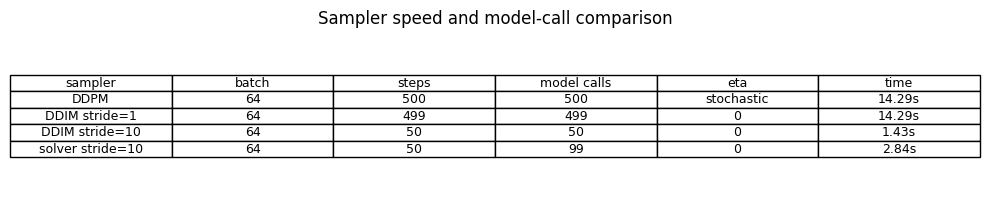

In [ ]:
def last_timing(label):
    matches = [row["seconds"] for row in timing_log if row["label"] == label]
    return matches[-1] if matches else float("nan")


def timing_for(label, fn):
    """Reuse an existing timing if possible; otherwise run the benchmark once."""
    seconds = last_timing(label)
    if np.isfinite(seconds):
        return seconds
    timed(label, fn)
    return last_timing(label)


def ddim_step_count(step_stride):
    times = list(range(cfg.T - 1, -1, -step_stride))
    if times[-1] != 0:
        times.append(0)
    return len(times) - 1


def seconds_text(seconds):
    return "not run" if not np.isfinite(seconds) else f"{seconds:.2f}s"


benchmark_labels = continuous_sample_labels
benchmark_batch = int(benchmark_labels.shape[0])
ddim_demo_label = f"DDIM benchmark stride={DEMO_DDIM_STRIDE} batch={benchmark_batch}"

sampler_specs = [
    {
        "sampler": "DDPM",
        "batch": benchmark_batch,
        "steps": cfg.T,
        "model calls": cfg.T,
        "eta": "stochastic",
        "timing label": f"DDPM benchmark batch={benchmark_batch}",
        "fn": lambda: ddpm_sample(model, benchmark_labels, guidance_scale=SAMPLE_GUIDANCE, record=False),
    },
    {
        "sampler": f"DDIM stride={DDIM_FULL_STRIDE}",
        "batch": benchmark_batch,
        "steps": ddim_step_count(DDIM_FULL_STRIDE),
        "model calls": ddim_step_count(DDIM_FULL_STRIDE),
        "eta": "0",
        "timing label": f"DDIM benchmark stride={DDIM_FULL_STRIDE} batch={benchmark_batch}",
        "fn": lambda: ddim_sample(model, benchmark_labels, step_stride=DDIM_FULL_STRIDE, eta=0.0, guidance_scale=SAMPLE_GUIDANCE, record=False),
    },
    {
        "sampler": f"DDIM stride={DEMO_DDIM_STRIDE}",
        "batch": benchmark_batch,
        "steps": ddim_step_count(DEMO_DDIM_STRIDE),
        "model calls": ddim_step_count(DEMO_DDIM_STRIDE),
        "eta": "0",
        "timing label": ddim_demo_label,
        "fn": lambda: ddim_sample(model, benchmark_labels, step_stride=DEMO_DDIM_STRIDE, eta=0.0, guidance_scale=SAMPLE_GUIDANCE, record=False),
    },
    {
        "sampler": f"solver stride={SOLVER_STRIDE}",
        "batch": benchmark_batch,
        "steps": ddim_step_count(SOLVER_STRIDE),
        "model calls": 2 * ddim_step_count(SOLVER_STRIDE) - 1,
        "eta": "0",
        "timing label": f"solver benchmark stride={SOLVER_STRIDE} batch={benchmark_batch}",
        "fn": lambda: solver_sample(model, benchmark_labels, step_stride=SOLVER_STRIDE, guidance_scale=SAMPLE_GUIDANCE, record=False),
    },
]

sampler_rows = []
for spec in sampler_specs:
    seconds = timing_for(spec["timing label"], spec["fn"])
    sampler_rows.append({
        "sampler": spec["sampler"],
        "batch": spec["batch"],
        "steps": spec["steps"],
        "model calls": spec["model calls"],
        "eta": spec["eta"],
        "time": seconds_text(seconds),
    })

columns = ["sampler", "batch", "steps", "model calls", "eta", "time"]
print(" | ".join(f"{col:>12}" for col in columns))
print("-" * 82)
for row in sampler_rows:
    print(" | ".join(f"{str(row[col]):>12}" for col in columns))

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis("off")
ax.table(
    cellText=[[row[col] for col in columns] for row in sampler_rows],
    colLabels=columns,
    loc="center",
    cellLoc="center",
)
ax.set_title("Sampler speed and model-call comparison")
plt.tight_layout()
plt.show()


## 13. Optional extension: sequence diffusion on discrete MNIST tokens

This section is optional for a 1-hour lab and is off by default. It is controlled by `RUN_SEQUENCE_EXTENSION` in the configuration cell.

The PDF frames the lab around diffusion for images and sequences. This section keeps the same high-level idea, but swaps Gaussian corruption for token masking.

The analogy is the important part: define an easy forward corruption process, train a model to undo one corrupted state, then generate by repeatedly applying learned reverse updates. The data type changes, so the corruption distribution changes too.

The previous sections used continuous Gaussian noise on images. Here we switch to a discrete version:

- Resize MNIST to `14 x 14`.
- Quantize each pixel into one of `num_bins` token values.
- Corrupt tokens by replacing them with a special mask token.
- Train a model to recover the original token values.
- Sample by gradually unmasking tokens.

This mirrors masked generative models for sequences and images. It is useful if you want to connect diffusion ideas to discrete data, but it introduces a second modeling style, so it can also be assigned as after-class material.

Unlike the main MNIST diffusion model, this extension does not use the Gaussian `q_sample` formula. The shared lesson is the modelling pattern, not the exact continuous-noise equations.

To run it, set `RUN_SEQUENCE_EXTENSION = True` and run the cells in this section.


In [ ]:
if RUN_SEQUENCE_EXTENSION:
    @dataclass
    class SeqConfig:
        # Work at lower resolution so the discrete-token model is fast.
        image_size: int = 14
        num_bins: int = 8

        # Sequence corruption schedule. Here beta means mask probability added over time.
        T: int = 100
        beta_start: float = 1e-3
        beta_end: float = 3.5e-2

        batch_size: int = 128
        lr: float = 1e-3
        train_subset: int = 20000
        val_subset: int = 2000
        num_epochs: int = 20

        # Small convolutional token denoiser.
        d_model: int = 96
        num_layers: int = 5

        # Some training examples are forced to be fully masked, which helps generation.
        full_mask_train_prob: float = 0.1

    if LAB_MODE == "fast":
        seq_cfg = SeqConfig(train_subset=5000, val_subset=1000, num_epochs=5, d_model=64, num_layers=3)
    else:
        seq_cfg = SeqConfig()

    seq_cfg
else:
    print('Skipping sequence config. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


sequence length: 196
vocab size: 9 (8 bins + 1 mask)
train subset: 20000
val subset: 2000


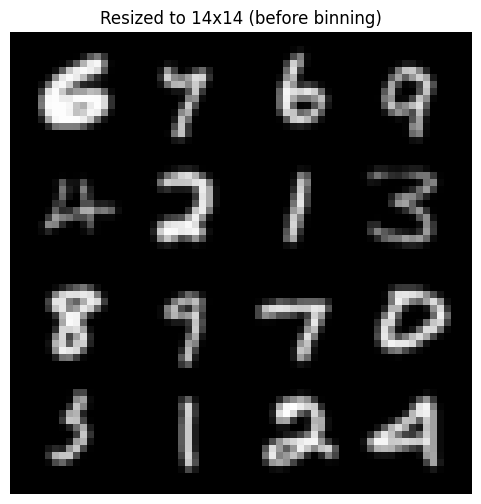

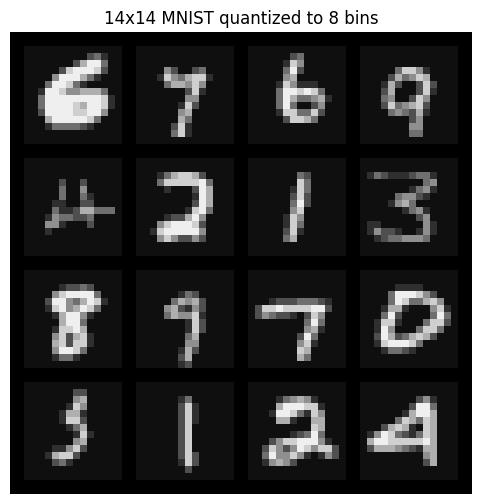

In [ ]:
if RUN_SEQUENCE_EXTENSION:
    seq_mask_id = seq_cfg.num_bins
    seq_vocab_size = seq_cfg.num_bins + 1
    seq_len = seq_cfg.image_size * seq_cfg.image_size
    seq_resize = transforms.Resize((seq_cfg.image_size, seq_cfg.image_size), antialias=True)


    def image_to_token_ids(x, num_bins):
        """Quantize a [-1, 1] image into integer token IDs."""
        x01 = (x + 1.0) / 2.0
        return torch.clamp((x01 * num_bins).long(), max=num_bins - 1)


    def token_ids_to_image(x_tokens, num_bins, mask_id=None, height=14, width=14):
        """Map token IDs back to approximate image intensities for visualization."""
        x_vis = x_tokens.float().clone()
        if mask_id is not None:
            # Show masked tokens as the brightest valid bin before coloring them red elsewhere.
            x_vis = torch.clamp(x_vis, max=num_bins - 1)
        x_vis = 2.0 * ((x_vis + 0.5) / num_bins) - 1.0
        return x_vis.view(-1, 1, height, width)


    def token_ids_to_rgb(x_tokens, num_bins, mask_id, height=14, width=14):
        """Render discrete token images, coloring mask tokens red."""
        gray = ((token_ids_to_image(x_tokens, num_bins, mask_id=mask_id, height=height, width=width) + 1.0) / 2.0).clamp(0, 1)
        rgb = gray.repeat(1, 3, 1, 1)
        mask = (x_tokens == mask_id).view(-1, 1, height, width)
        rgb[:, 0][mask[:, 0]] = 1.0
        rgb[:, 1][mask[:, 0]] = 0.15
        rgb[:, 2][mask[:, 0]] = 0.15
        return rgb


    def show_token_images(batch, title='', nrow=4, figsize=(6, 6), mask_id=None):
        """Show a grid of tokenized images."""
        batch = batch.detach().cpu()
        if mask_id is None:
            images = token_ids_to_image(batch, seq_cfg.num_bins, height=seq_cfg.image_size, width=seq_cfg.image_size)
            grid = make_grid(((images + 1.0) / 2.0).clamp(0, 1)[:nrow * nrow], nrow=nrow, padding=2)
            plt.figure(figsize=figsize)
            plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray', vmin=0.0, vmax=1.0)
        else:
            rgb = token_ids_to_rgb(batch, seq_cfg.num_bins, mask_id=mask_id, height=seq_cfg.image_size, width=seq_cfg.image_size)
            grid = make_grid(rgb[:nrow * nrow], nrow=nrow, padding=2)
            plt.figure(figsize=figsize)
            plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
        plt.axis('off')
        plt.title(title)
        plt.show()


    def preprocess_seq_subset(subset, n_items):
        """Resize images, quantize pixels, and store labels in tensors for fast training."""
        small_images, tokens, labels = [], [], []
        for i in range(min(n_items, len(subset))):
            x, y = subset[i]
            x_small = seq_resize(x)
            x_tokens = image_to_token_ids(x_small, seq_cfg.num_bins).view(-1)
            small_images.append(x_small)
            tokens.append(x_tokens)
            labels.append(y)
        return torch.stack(small_images), torch.stack(tokens), torch.tensor(labels, dtype=torch.long)


    seq_train_images_small, seq_train_tokens, seq_train_labels = preprocess_seq_subset(train_base, seq_cfg.train_subset)
    seq_val_images_small, seq_val_tokens, seq_val_labels = preprocess_seq_subset(val_base, seq_cfg.val_subset)

    seq_train_loader = DataLoader(
        TensorDataset(seq_train_tokens, seq_train_labels),
        batch_size=seq_cfg.batch_size,
        shuffle=True,
    )
    seq_val_loader = DataLoader(
        TensorDataset(seq_val_tokens, seq_val_labels),
        batch_size=seq_cfg.batch_size,
        shuffle=False,
    )

    print('sequence length:', seq_len)
    print('vocab size:', seq_vocab_size, '(8 bins + 1 mask)')
    print('train subset:', len(seq_train_tokens))
    print('val subset:', len(seq_val_tokens))
    show_images(
        seq_train_images_small[:16],
        title='Resized to 14x14 (before binning)',
        nrow=4,
        figsize=(6, 6),
    )
    show_token_images(
        seq_train_tokens[:16],
        title='14x14 MNIST quantized to 8 bins',
        nrow=4,
        figsize=(6, 6),
    )
else:
    print('Skipping sequence preprocessing. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


beta range: 0.0010000000474974513 -> 0.03500000014901161
mask prob range: 0.0009999871253967285 -> 0.8382160067558289


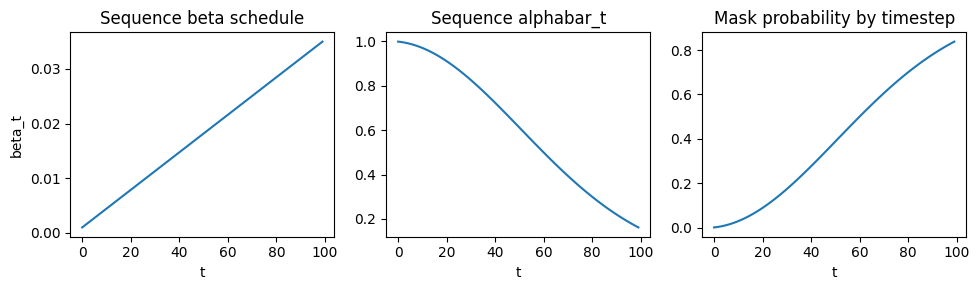

In [ ]:
if RUN_SEQUENCE_EXTENSION:
    # Reuse the beta/alpha/alphabar idea, but interpret 1 - alphabar as mask probability.
    seq_betas = torch.linspace(seq_cfg.beta_start, seq_cfg.beta_end, seq_cfg.T, dtype=torch.float32)
    seq_alphas = 1.0 - seq_betas
    seq_alphabars = torch.cumprod(seq_alphas, dim=0)
    seq_mask_probs = 1.0 - seq_alphabars

    print('beta range:', float(seq_betas[0]), '->', float(seq_betas[-1]))
    print('mask prob range:', float(seq_mask_probs[0]), '->', float(seq_mask_probs[-1]))

    plt.figure(figsize=(10, 3))
    plt.subplot(1, 3, 1)
    plt.plot(seq_betas.numpy())
    plt.title('Sequence beta schedule')
    plt.xlabel('t')
    plt.ylabel('beta_t')

    plt.subplot(1, 3, 2)
    plt.plot(seq_alphabars.numpy())
    plt.title('Sequence alphabar_t')
    plt.xlabel('t')

    plt.subplot(1, 3, 3)
    plt.plot(seq_mask_probs.numpy())
    plt.title('Mask probability by timestep')
    plt.xlabel('t')

    plt.tight_layout()
    plt.show()
else:
    print('Skipping sequence schedule. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


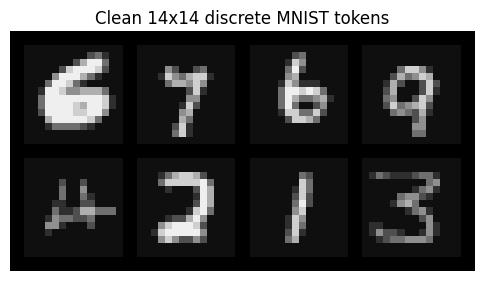

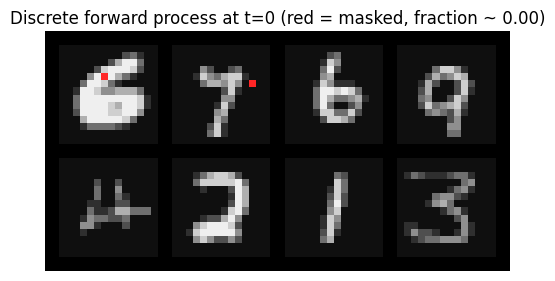

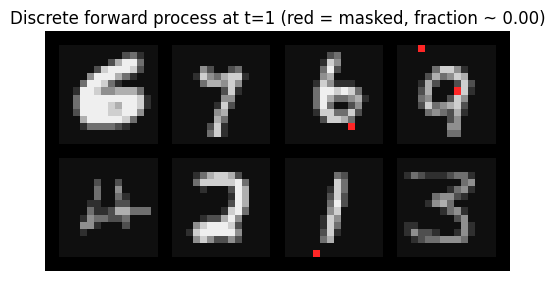

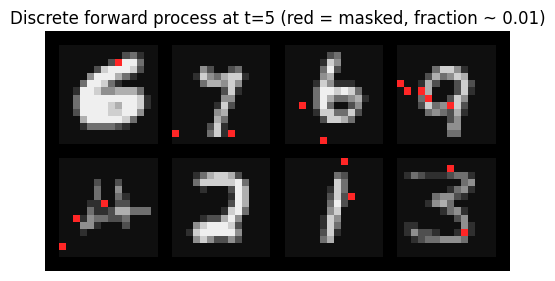

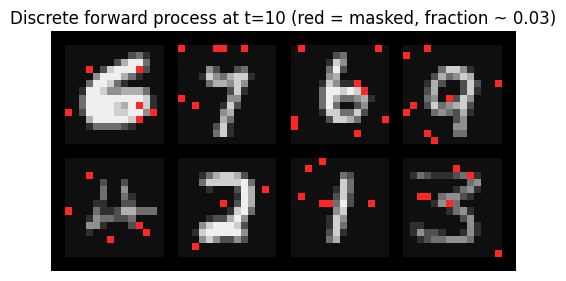

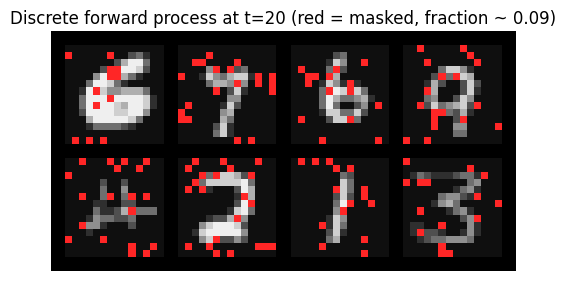

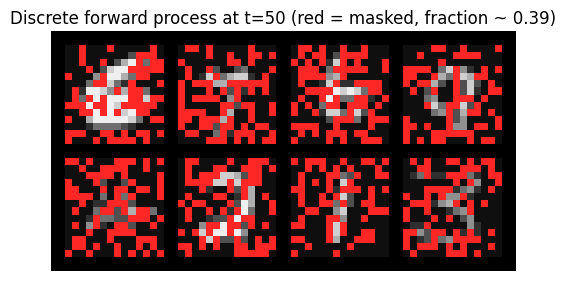

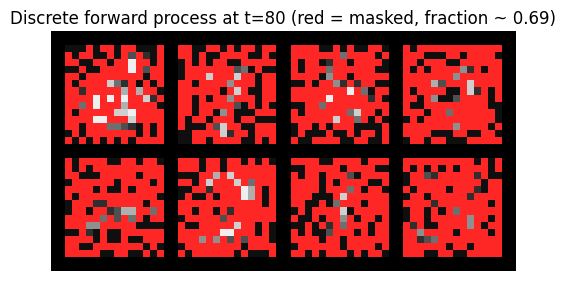

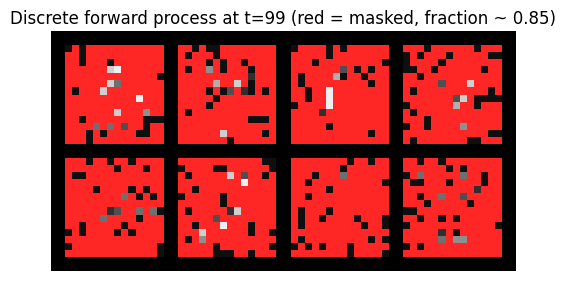

In [ ]:
if RUN_SEQUENCE_EXTENSION:
    def q_sample_seq(x0, t):
        """Discrete analogue of forward noising: replace tokens with [MASK]."""
        # The image model added Gaussian noise; for discrete tokens we cannot add a
        # small real-valued epsilon, so the corruption process hides tokens instead.
        # seq_mask_probs plays the same schedule role as 1 - alphabar_t above.
        probs = seq_mask_probs.to(x0.device)[t].unsqueeze(1)
        mask = torch.rand(x0.shape, device=x0.device) < probs
        xt = x0.clone()
        xt[mask] = seq_mask_id
        return xt, mask


    preview_tokens = seq_train_tokens[:8]
    show_token_images(
        preview_tokens,
        title='Clean 14x14 discrete MNIST tokens',
        nrow=4,
        figsize=(6, 6),
    )

    # Visualize how the masked-token forward process becomes more destructive over time.
    preview_ts = sorted({
        0,
        min(seq_cfg.T - 1, 1),
        min(seq_cfg.T - 1, 5),
        seq_cfg.T // 10,
        seq_cfg.T // 5,
        seq_cfg.T // 2,
        (4 * seq_cfg.T) // 5,
        seq_cfg.T - 1,
    })
    for t in preview_ts:
        xt, mask = q_sample_seq(preview_tokens, torch.full((preview_tokens.shape[0],), t, dtype=torch.long))
        show_token_images(
            xt,
            title=f'Discrete forward process at t={t} (red = masked, fraction ~ {float(mask.float().mean()):.2f})',
            nrow=4,
            figsize=(6, 6),
            mask_id=seq_mask_id,
        )
else:
    print('Skipping sequence forward-process preview. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


In [ ]:
if RUN_SEQUENCE_EXTENSION:
    class SeqResBlock(nn.Module):
        """Residual convolutional block for token-grid features."""

        def __init__(self, channels, cond_dim):
            super().__init__()
            self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
            self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
            self.norm1 = nn.GroupNorm(8, channels)
            self.norm2 = nn.GroupNorm(8, channels)
            self.cond_proj = nn.Linear(cond_dim, channels)

        def forward(self, x, cond):
            h = self.conv1(x)
            h = self.norm1(h)
            h = F.silu(h)
            h = h + self.cond_proj(cond)[:, :, None, None]
            h = self.conv2(h)
            h = self.norm2(h)
            h = F.silu(h)
            return x + h


    class TinySeqDenoiser(nn.Module):
        """Predict original token values from masked token grids."""

        def __init__(self, vocab_size, d_model=96, image_size=14, T=100, num_layers=5, num_classes=10):
            super().__init__()
            self.image_size = image_size
            self.token_emb = nn.Embedding(vocab_size, d_model)
            self.pos_emb = nn.Embedding(image_size * image_size, d_model)
            self.time_emb = nn.Embedding(T, d_model)
            self.label_emb = nn.Embedding(num_classes, d_model)
            self.blocks = nn.ModuleList([SeqResBlock(d_model, d_model) for _ in range(num_layers)])
            self.out_norm = nn.GroupNorm(8, d_model)
            self.head = nn.Conv2d(d_model, vocab_size, kernel_size=1)

        def forward(self, x, t, y):
            b, L = x.shape
            pos = torch.arange(L, device=x.device).unsqueeze(0).expand(b, L)

            # Token and position embeddings describe the current corrupted sequence.
            # Timestep and label embeddings are the discrete counterpart of conditioning
            # epsilon_theta(x_t, t, y) in the image model.
            cond = self.time_emb(t) + self.label_emb(y)
            h = self.token_emb(x) + self.pos_emb(pos)

            # Treat the token sequence as a 2D image grid so small convolutions can use
            # local MNIST structure, even though the data is represented as tokens.
            h = h.view(b, self.image_size, self.image_size, -1).permute(0, 3, 1, 2)

            for block in self.blocks:
                h = block(h, cond)

            h = self.out_norm(h)
            h = F.silu(h)
            logits = self.head(h)
            logits = logits.permute(0, 2, 3, 1).reshape(b, L, -1)
            return logits


    seq_model = TinySeqDenoiser(
        vocab_size=seq_vocab_size,
        d_model=seq_cfg.d_model,
        image_size=seq_cfg.image_size,
        T=seq_cfg.T,
        num_layers=seq_cfg.num_layers,
        num_classes=10,
    ).to(device)
    seq_opt = torch.optim.Adam(seq_model.parameters(), lr=seq_cfg.lr)
    print('sequence model params:', sum(p.numel() for p in seq_model.parameters()) / 1e6, 'M')
else:
    print('Skipping sequence model setup. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


sequence model params: 0.910185 M


epoch 01 | train 0.6127 | val 0.5093
epoch 02 | train 0.4822 | val 0.4659
epoch 03 | train 0.4457 | val 0.4434
epoch 04 | train 0.4277 | val 0.4244
epoch 05 | train 0.4143 | val 0.4202
epoch 06 | train 0.4084 | val 0.4151
epoch 07 | train 0.4029 | val 0.4005
epoch 08 | train 0.4029 | val 0.4048
epoch 09 | train 0.3957 | val 0.4030
epoch 10 | train 0.3932 | val 0.4027
epoch 11 | train 0.3919 | val 0.3875
epoch 12 | train 0.3885 | val 0.3882
epoch 13 | train 0.3861 | val 0.3881
epoch 14 | train 0.3843 | val 0.3861
epoch 15 | train 0.3839 | val 0.3824
epoch 16 | train 0.3796 | val 0.3833
epoch 17 | train 0.3795 | val 0.3924
epoch 18 | train 0.3780 | val 0.3749
epoch 19 | train 0.3771 | val 0.3846
epoch 20 | train 0.3734 | val 0.3740


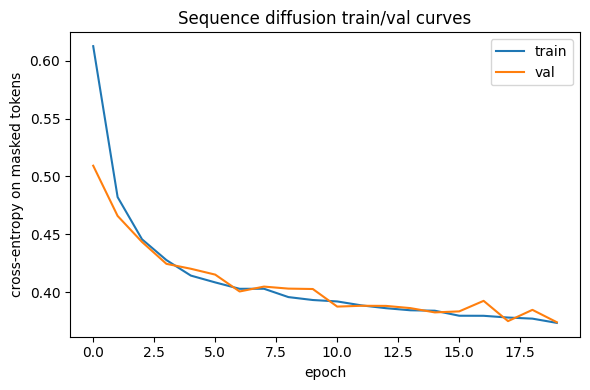

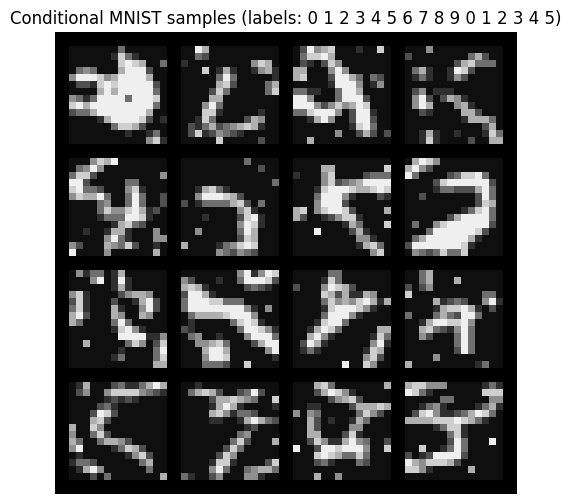

In [ ]:
if RUN_SEQUENCE_EXTENSION:
    @torch.no_grad()
    def predict_token_bins(model, x, t, y):
        """Return the most likely non-mask token and its confidence at each position."""
        logits = model(x, t, y)[..., :seq_cfg.num_bins]
        probs = torch.softmax(logits, dim=-1)
        conf, pred = probs.max(dim=-1)
        return pred, conf


    def seq_loss(model, x0, y):
        """Train the sequence denoiser to reconstruct only the tokens that were masked."""
        b = x0.shape[0]
        t = torch.randint(0, seq_cfg.T, (b,), device=x0.device)
        xt, mask = q_sample_seq(x0, t)

        # Occasionally train on fully masked inputs so generation from high-noise states is less surprising.
        force_full = (t >= int(0.8 * seq_cfg.T)) & (torch.rand((b,), device=x0.device) < seq_cfg.full_mask_train_prob)
        if force_full.any():
            xt = xt.clone()
            mask = mask.clone()
            xt[force_full] = seq_mask_id
            mask[force_full] = True

        logits = model(xt, t, y)[..., :seq_cfg.num_bins]

        # Cross entropy is computed only where the forward process actually hid a token.
        # This mirrors the image objective: predict the missing/corrupted part, not
        # every value that was already visible to the model.
        return F.cross_entropy(logits[mask], x0[mask]) if mask.any() else logits.sum() * 0.0


    @torch.no_grad()
    def evaluate_seq(model, loader, max_batches=20):
        """Fast validation loop for the masked-token denoiser."""
        model.eval()
        losses = []
        for i, (x, y) in enumerate(loader):
            if i >= max_batches:
                break
            x = x.to(device)
            y = y.to(device)
            losses.append(seq_loss(model, x, y).item())
        return float(np.mean(losses))


    seq_train_losses, seq_val_losses = [], []
    for epoch in range(seq_cfg.num_epochs):
        seq_model.train()
        running = []

        for x, y in seq_train_loader:
            x = x.to(device)
            y = y.to(device)
            seq_opt.zero_grad()
            loss = seq_loss(seq_model, x, y)
            loss.backward()
            seq_opt.step()
            running.append(loss.item())

        train_loss = float(np.mean(running))
        val_loss = evaluate_seq(seq_model, seq_val_loader)
        seq_train_losses.append(train_loss)
        seq_val_losses.append(val_loss)
        print(f'epoch {epoch + 1:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

    plt.figure(figsize=(6, 4))
    plt.plot(seq_train_losses, label='train')
    plt.plot(seq_val_losses, label='val')
    plt.xlabel('epoch')
    plt.ylabel('cross-entropy on masked tokens')
    plt.title('Sequence diffusion train/val curves')
    plt.legend()
    plt.tight_layout()
    plt.show()


    @torch.no_grad()
    def sample_sequence(model, labels, record=False):
        """Generate discrete samples by repeatedly predicting and unmasking tokens."""
        model.eval()
        labels = labels.to(device)
        n = labels.shape[0]

        # Start from the noisiest state actually seen during training: mostly masked,
        # partly random. This is the discrete version of starting image sampling from x_T.
        x = torch.randint(0, seq_cfg.num_bins, (n, seq_len), device=device, dtype=torch.long)
        init_mask = torch.rand((n, seq_len), device=device) < float(seq_mask_probs[-1])
        x[init_mask] = seq_mask_id
        history = []

        record_steps = sorted({0, seq_cfg.T // 4, seq_cfg.T // 2, (3 * seq_cfg.T) // 4, seq_cfg.T - 1}, reverse=True)

        for t in reversed(range(seq_cfg.T)):
            t_batch = torch.full((n,), t, device=device, dtype=torch.long)
            pred, conf = predict_token_bins(model, x, t_batch, labels)

            # Fill every currently masked position with the model's best guess.
            still_masked = x == seq_mask_id
            next_x = x.clone()
            next_x[still_masked] = pred[still_masked]

            if t > 0:
                # Move to the next lower noise level by re-masking only a smaller
                # fraction of tokens, analogous to stepping from x_t toward x_{t-1}.
                keep_ratio = float(seq_mask_probs[t - 1] / max(seq_mask_probs[t], 1e-8))
                x = next_x.clone()
                for b in range(n):
                    masked_idx = torch.nonzero(still_masked[b], as_tuple=False).squeeze(-1)
                    if masked_idx.numel() == 0:
                        continue

                    # Low-confidence positions stay masked longer; high-confidence positions become fixed.
                    # This is a simple discrete replacement for gradually reducing noise.
                    keep_count = int(round(keep_ratio * masked_idx.numel()))
                    keep_count = max(0, min(keep_count, masked_idx.numel()))
                    if keep_count > 0:
                        masked_conf = conf[b, masked_idx]
                        keep_order = torch.argsort(masked_conf, descending=False)
                        keep_idx = masked_idx[keep_order[:keep_count]]
                        x[b, keep_idx] = seq_mask_id
            else:
                x = next_x

            if record and t in record_steps:
                history.append((t, x.detach().cpu()))

        return x.detach().cpu(), history


    sample_labels = torch.arange(16, dtype=torch.long) % 10
    seq_samples, _ = sample_sequence(seq_model, sample_labels, record=False)
    show_token_images(
        seq_samples,
        title='Conditional MNIST samples (labels: 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5)',
        nrow=4,
        figsize=(6, 6),
    )
else:
    print('Skipping sequence training and sampling. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


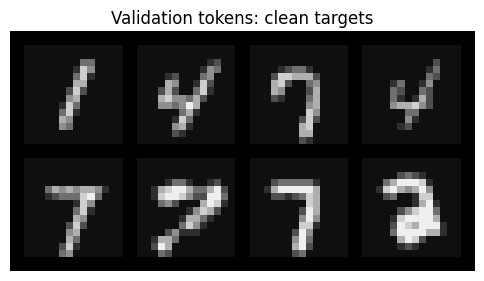

validation labels: [1, 4, 7, 4, 7, 7, 7, 2]


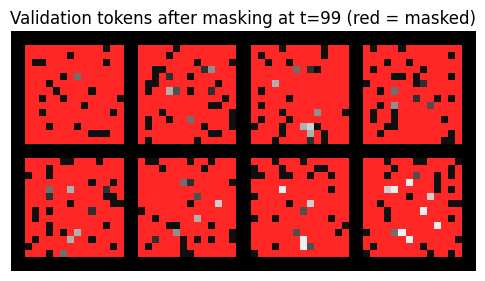

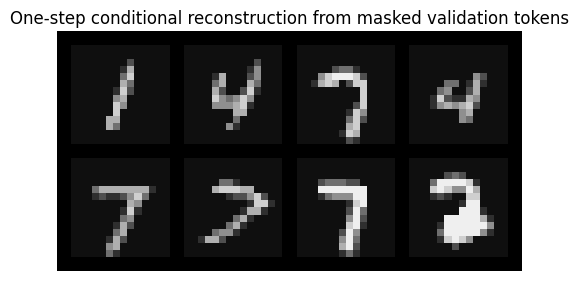

mean confidence on masked positions: 0.836539626121521


In [ ]:
if RUN_SEQUENCE_EXTENSION:
    @torch.no_grad()
    def reconstruct_sequence(model, x0, y, t_value):
        """Mask validation tokens at one timestep and reconstruct them in a single model pass."""
        model.eval()
        t = torch.full((x0.shape[0],), t_value, device=x0.device, dtype=torch.long)
        xt, mask = q_sample_seq(x0, t)
        pred, conf = predict_token_bins(model, xt, t, y)
        recon = xt.clone()
        recon[mask] = pred[mask]
        return xt.cpu(), recon.cpu(), mask.cpu(), conf.cpu()


    val_example = seq_val_tokens[:8].to(device)
    val_labels = seq_val_labels[:8].to(device)
    recon_t = seq_cfg.T - 1
    masked_tokens, recon_tokens, recon_mask, recon_conf = reconstruct_sequence(seq_model, val_example, val_labels, recon_t)

    show_token_images(
        seq_val_tokens[:8],
        title='Validation tokens: clean targets',
        nrow=4,
        figsize=(6, 6),
    )
    print('validation labels:', seq_val_labels[:8].tolist())
    show_token_images(
        masked_tokens,
        title=f'Validation tokens after masking at t={recon_t} (red = masked)',
        nrow=4,
        figsize=(6, 6),
        mask_id=seq_mask_id,
    )
    show_token_images(
        recon_tokens,
        title='One-step conditional reconstruction from masked validation tokens',
        nrow=4,
        figsize=(6, 6),
    )
    print('mean confidence on masked positions:', float(recon_conf[recon_mask].mean()))
else:
    print('Skipping sequence reconstruction diagnostic. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')


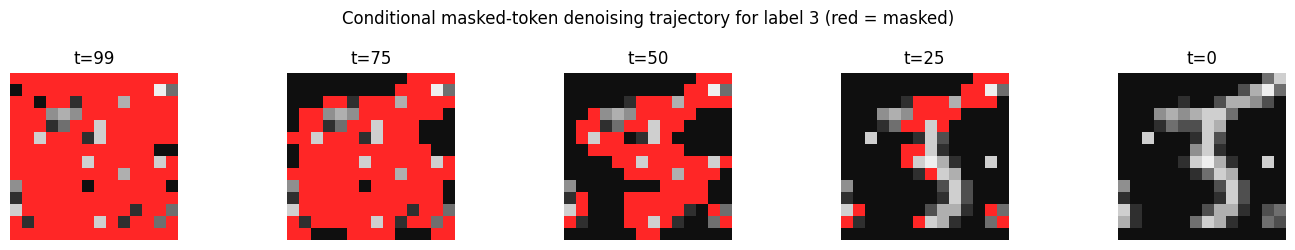

In [ ]:
if RUN_SEQUENCE_EXTENSION:
    # Record the full discrete denoising trajectory for one requested label.
    trajectory_labels = torch.tensor([3], dtype=torch.long)
    seq_final_x, seq_history = sample_sequence(seq_model, trajectory_labels, record=True)

    fig, axes = plt.subplots(1, len(seq_history), figsize=(14, 2.5))
    axes = np.atleast_1d(axes).ravel()
    for ax, (t, tokens) in zip(axes, seq_history):
        img = token_ids_to_rgb(tokens[:1], seq_cfg.num_bins, mask_id=seq_mask_id, height=seq_cfg.image_size, width=seq_cfg.image_size)[0]
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f't={t}')
        ax.axis('off')

    plt.suptitle('Conditional masked-token denoising trajectory for label 3 (red = masked)')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping sequence trajectory plot. Set RUN_SEQUENCE_EXTENSION=True to run this optional section.')
